In [1]:
import numpy as np
import pandas as pd
from decimal import Decimal
import re

In [2]:
bitcoin_blocks = pd.read_csv("../data/real_bitcoin_blocks_raw.csv")
coinbase_addresses = pd.read_csv("../data/coinbase_addresses_full.csv")

In [3]:
# Formatting the real_outputs column data with regex and decimal conversion

# This regex restores the comma between entries before we hand the string to eval().
def parse_outputs(s):
    fixed = re.sub(r"\}\s*\n\s*\{", "}, {", s)
    return eval(fixed, {"Decimal": Decimal, "__builtins__": {}})

coinbase_addresses["real_outputs_parsed"] = coinbase_addresses["real_outputs"].apply(parse_outputs)
coinbase_addresses["n_addresses"] = coinbase_addresses["real_outputs_parsed"].apply(len)

In [4]:
coinbase_addresses['block_timestamp'] = pd.to_datetime(coinbase_addresses['block_timestamp'])
coinbase_addresses['block_timestamp'].describe()

count                              810909
mean     2016-05-13 12:52:27.924965+00:00
min             2009-01-03 18:15:05+00:00
25%             2012-10-10 22:19:35+00:00
50%             2016-04-02 20:55:40+00:00
75%             2019-12-15 06:03:40+00:00
max             2023-10-06 13:37:21+00:00
Name: block_timestamp, dtype: object

In [5]:
def get_primary_miner(coinbase_payouts):
    if coinbase_payouts == []:
        return (None, 0)
    
    highest_payout = max(coinbase_payouts, key=lambda x: x["value"])
    
    highest_payouts = []
    for payout in coinbase_payouts:
        if payout["value"] == highest_payout["value"]:
            highest_payouts.append(payout)
    
    return (highest_payouts[0]["address"], len(highest_payouts))

In [6]:
coinbase_addresses['primary_miner_result'] = coinbase_addresses['real_outputs_parsed'].apply(get_primary_miner)
coinbase_addresses['primary_miner_address'] = coinbase_addresses['primary_miner_result'].str[0]
coinbase_addresses['primary_miner_ties'] = coinbase_addresses['primary_miner_result'].str[1]
coinbase_addresses

,block_number,block_timestamp,real_outputs,real_outputs_parsed,n_addresses,primary_miner_result,primary_miner_address,primary_miner_ties
0,755688,2022-09-25 21:17:12+00:00,[{'address': '18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5...,[{'address': '18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5...,1,"(18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5PX, 1)",18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5PX,1
1,755658,2022-09-25 15:04:25+00:00,[{'address': '18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5...,[{'address': '18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5...,1,"(18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5PX, 1)",18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5PX,1
2,756371,2022-09-30 13:14:40+00:00,[{'address': '18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5...,[{'address': '18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5...,1,"(18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5PX, 1)",18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5PX,1
3,754843,2022-09-19 20:29:55+00:00,[{'address': '3L8Ck6bm3sve1vJGKo6Ht2k167YKSKi8...,[{'address': '3L8Ck6bm3sve1vJGKo6Ht2k167YKSKi8...,1,"(3L8Ck6bm3sve1vJGKo6Ht2k167YKSKi8TZ, 1)",3L8Ck6bm3sve1vJGKo6Ht2k167YKSKi8TZ,1
4,755220,2022-09-22 11:21:06+00:00,[{'address': '3C9sAKXrBVpJVe3b738yik4LPHpPmceB...,[{'address': '3C9sAKXrBVpJVe3b738yik4LPHpPmceB...,1,"(3C9sAKXrBVpJVe3b738yik4LPHpPmceBgd, 1)",3C9sAKXrBVpJVe3b738yik4LPHpPmceBgd,1
...,...,...,...,...,...,...,...,...
810904,762082,2022-11-07 04:51:06+00:00,[{'address': '12KKDt4Mj7N5UAkQMN7LtPZMayenXHa8...,[{'address': '12KKDt4Mj7N5UAkQMN7LtPZMayenXHa8...,1,"(12KKDt4Mj7N5UAkQMN7LtPZMayenXHa8KL, 1)",12KKDt4Mj7N5UAkQMN7LtPZMayenXHa8KL,1
810905,761961,2022-11-06 09:03:17+00:00,[{'address': '12KKDt4Mj7N5UAkQMN7LtPZMayenXHa8...,[{'address': '12KKDt4Mj7N5UAkQMN7LtPZMayenXHa8...,1,"(12KKDt4Mj7N5UAkQMN7LtPZMayenXHa8KL, 1)",12KKDt4Mj7N5UAkQMN7LtPZMayenXHa8KL,1
810906,763253,2022-11-15 08:27:13+00:00,[{'address': '12KKDt4Mj7N5UAkQMN7LtPZMayenXHa8...,[{'address': '12KKDt4Mj7N5UAkQMN7LtPZMayenXHa8...,1,"(12KKDt4Mj7N5UAkQMN7LtPZMayenXHa8KL, 1)",12KKDt4Mj7N5UAkQMN7LtPZMayenXHa8KL,1
810907,762893,2022-11-12 15:41:42+00:00,[{'address': '18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5...,[{'address': '18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5...,1,"(18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5PX, 1)",18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5PX,1


In [7]:
# join both dataframes
merged_df = pd.merge(bitcoin_blocks, coinbase_addresses, on='block_number', how='inner')
merged_df

,number,timestamp,size,transaction_count,bits,block_number,total_output_satoshis,total_output_satoshis_excl_coinbase,total_fee_satoshis,tx_count_check,difficulty,block_timestamp,real_outputs,real_outputs_parsed,n_addresses,primary_miner_result,primary_miner_address,primary_miner_ties
0,0,2009-01-03 18:15:05+00:00,285,1,1d00ffff,0,5.000000e+09,0.000000e+00,0.0,1,1.000000e+00,2009-01-03 18:15:05+00:00,[{'address': '1A1zP1eP5QGefi2DMPTfTL5SLmv7Divf...,[{'address': '1A1zP1eP5QGefi2DMPTfTL5SLmv7Divf...,1,"(1A1zP1eP5QGefi2DMPTfTL5SLmv7DivfNa, 1)",1A1zP1eP5QGefi2DMPTfTL5SLmv7DivfNa,1
1,1,2009-01-09 02:54:25+00:00,215,1,1d00ffff,1,5.000000e+09,0.000000e+00,0.0,1,1.000000e+00,2009-01-09 02:54:25+00:00,[{'address': '12c6DSiU4Rq3P4ZxziKxzrL5LmMBrzjr...,[{'address': '12c6DSiU4Rq3P4ZxziKxzrL5LmMBrzjr...,1,"(12c6DSiU4Rq3P4ZxziKxzrL5LmMBrzjrJX, 1)",12c6DSiU4Rq3P4ZxziKxzrL5LmMBrzjrJX,1
2,2,2009-01-09 02:55:44+00:00,215,1,1d00ffff,2,5.000000e+09,0.000000e+00,0.0,1,1.000000e+00,2009-01-09 02:55:44+00:00,[{'address': '1HLoD9E4SDFFPDiYfNYnkBLQ85Y51J3Z...,[{'address': '1HLoD9E4SDFFPDiYfNYnkBLQ85Y51J3Z...,1,"(1HLoD9E4SDFFPDiYfNYnkBLQ85Y51J3Zb1, 1)",1HLoD9E4SDFFPDiYfNYnkBLQ85Y51J3Zb1,1
3,3,2009-01-09 03:02:53+00:00,215,1,1d00ffff,3,5.000000e+09,0.000000e+00,0.0,1,1.000000e+00,2009-01-09 03:02:53+00:00,[{'address': '1FvzCLoTPGANNjWoUo6jUGuAG3wg1w4Y...,[{'address': '1FvzCLoTPGANNjWoUo6jUGuAG3wg1w4Y...,1,"(1FvzCLoTPGANNjWoUo6jUGuAG3wg1w4YjR, 1)",1FvzCLoTPGANNjWoUo6jUGuAG3wg1w4YjR,1
4,4,2009-01-09 03:16:28+00:00,215,1,1d00ffff,4,5.000000e+09,0.000000e+00,0.0,1,1.000000e+00,2009-01-09 03:16:28+00:00,[{'address': '15ubicBBWFnvoZLT7GiU2qxjRaKJPdkD...,[{'address': '15ubicBBWFnvoZLT7GiU2qxjRaKJPdkD...,1,"(15ubicBBWFnvoZLT7GiU2qxjRaKJPdkDMG, 1)",15ubicBBWFnvoZLT7GiU2qxjRaKJPdkDMG,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
810904,810904,2023-10-06 12:36:45+00:00,1471359,2641,1704e90f,810904,7.607876e+11,7.601375e+11,25173010.0,2641,5.732151e+13,2023-10-06 12:36:45+00:00,[{'address': 'bc1qxhmdufsvnuaaaer4ynz88fspdsxq...,[{'address': 'bc1qxhmdufsvnuaaaer4ynz88fspdsxq...,1,"(bc1qxhmdufsvnuaaaer4ynz88fspdsxq2h9e9cetdj, 1)",bc1qxhmdufsvnuaaaer4ynz88fspdsxq2h9e9cetdj,1
810905,810905,2023-10-06 12:45:49+00:00,1427754,2288,1704e90f,810905,1.161340e+12,1.160692e+12,23663392.0,2288,5.732151e+13,2023-10-06 12:45:49+00:00,[{'address': 'bc1qxhmdufsvnuaaaer4ynz88fspdsxq...,[{'address': 'bc1qxhmdufsvnuaaaer4ynz88fspdsxq...,1,"(bc1qxhmdufsvnuaaaer4ynz88fspdsxq2h9e9cetdj, 1)",bc1qxhmdufsvnuaaaer4ynz88fspdsxq2h9e9cetdj,1
810906,810906,2023-10-06 12:50:15+00:00,1612966,2016,1704e90f,810906,4.643628e+11,4.637224e+11,15483511.0,2016,5.732151e+13,2023-10-06 12:50:15+00:00,[{'address': '1K6KoYC69NnafWJ7YgtrpwJxBLiijWqw...,[{'address': '1K6KoYC69NnafWJ7YgtrpwJxBLiijWqw...,2,"(1KFHE7w8BhaENAswwryaoccDb6qcT6DbYY, 1)",1KFHE7w8BhaENAswwryaoccDb6qcT6DbYY,1
810907,810907,2023-10-06 13:37:00+00:00,1486563,3496,1704e90f,810907,2.469789e+12,2.469101e+12,63223285.0,3496,5.732151e+13,2023-10-06 13:37:00+00:00,[{'address': '38XnPvu9PmonFU9WouPXUjYbW91wa5Me...,[{'address': '38XnPvu9PmonFU9WouPXUjYbW91wa5Me...,1,"(38XnPvu9PmonFU9WouPXUjYbW91wa5MerL, 1)",38XnPvu9PmonFU9WouPXUjYbW91wa5MerL,1


In [8]:
miner_block_counts = merged_df['primary_miner_address'].value_counts()
print(miner_block_counts)


primary_miner_address
1KFHE7w8BhaENAswwryaoccDb6qcT6DbYY            81237
18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5PX            34093
1CK6KHY6MHgYvmRQ4PAafKYDrg1ejbH1cE            27261
14cZMQk89mRYQkDEj8Rn25AnGoBi5H6uer            26204
1CjPR7Z5ZSyWk6WtXvSFgkptmpoi4UM9BC            23083
                                              ...  
3EHpvbs5ar7DWiux1AQ5JMB2zTBE6wzX7d                1
bc1qrm09asqsxh2l7pjxjlltm53tx689dp2amzupzq        1
bc1q6fu02uvz2ghz3e3avqvqsqscr2pp4xhnuqfxpa        1
bc1q2za4ejga366sn288273pty8trasn5zs4y9hqg6        1
15h4MFgMs3yGiGfXA7fqhpsTWMkQ95EFBB                1
Name: count, Length: 197095, dtype: int64


In [9]:
# Step A: for every row, look up how many blocks its own address has mined in total
# .map() works like a dictionary lookup applied to an entire column at once,
# and importantly, unlike direct indexing, .map() quietly returns NaN for addresses
# it can't find (like our two None addresses), instead of crashing
merged_df['own_block_count'] = merged_df['primary_miner_address'].map(miner_block_counts)

# Step B: for every row, decide: keep the real address if count >= 10, otherwise 'long_tail'
merged_df['miner_group'] = np.where(merged_df['own_block_count'] >= 10, merged_df['primary_miner_address'], 'long_tail')

merged_df

,number,timestamp,size,transaction_count,bits,block_number,total_output_satoshis,total_output_satoshis_excl_coinbase,total_fee_satoshis,tx_count_check,difficulty,block_timestamp,real_outputs,real_outputs_parsed,n_addresses,primary_miner_result,primary_miner_address,primary_miner_ties,own_block_count,miner_group
0,0,2009-01-03 18:15:05+00:00,285,1,1d00ffff,0,5.000000e+09,0.000000e+00,0.0,1,1.000000e+00,2009-01-03 18:15:05+00:00,[{'address': '1A1zP1eP5QGefi2DMPTfTL5SLmv7Divf...,[{'address': '1A1zP1eP5QGefi2DMPTfTL5SLmv7Divf...,1,"(1A1zP1eP5QGefi2DMPTfTL5SLmv7DivfNa, 1)",1A1zP1eP5QGefi2DMPTfTL5SLmv7DivfNa,1,1.0,long_tail
1,1,2009-01-09 02:54:25+00:00,215,1,1d00ffff,1,5.000000e+09,0.000000e+00,0.0,1,1.000000e+00,2009-01-09 02:54:25+00:00,[{'address': '12c6DSiU4Rq3P4ZxziKxzrL5LmMBrzjr...,[{'address': '12c6DSiU4Rq3P4ZxziKxzrL5LmMBrzjr...,1,"(12c6DSiU4Rq3P4ZxziKxzrL5LmMBrzjrJX, 1)",12c6DSiU4Rq3P4ZxziKxzrL5LmMBrzjrJX,1,1.0,long_tail
2,2,2009-01-09 02:55:44+00:00,215,1,1d00ffff,2,5.000000e+09,0.000000e+00,0.0,1,1.000000e+00,2009-01-09 02:55:44+00:00,[{'address': '1HLoD9E4SDFFPDiYfNYnkBLQ85Y51J3Z...,[{'address': '1HLoD9E4SDFFPDiYfNYnkBLQ85Y51J3Z...,1,"(1HLoD9E4SDFFPDiYfNYnkBLQ85Y51J3Zb1, 1)",1HLoD9E4SDFFPDiYfNYnkBLQ85Y51J3Zb1,1,1.0,long_tail
3,3,2009-01-09 03:02:53+00:00,215,1,1d00ffff,3,5.000000e+09,0.000000e+00,0.0,1,1.000000e+00,2009-01-09 03:02:53+00:00,[{'address': '1FvzCLoTPGANNjWoUo6jUGuAG3wg1w4Y...,[{'address': '1FvzCLoTPGANNjWoUo6jUGuAG3wg1w4Y...,1,"(1FvzCLoTPGANNjWoUo6jUGuAG3wg1w4YjR, 1)",1FvzCLoTPGANNjWoUo6jUGuAG3wg1w4YjR,1,1.0,long_tail
4,4,2009-01-09 03:16:28+00:00,215,1,1d00ffff,4,5.000000e+09,0.000000e+00,0.0,1,1.000000e+00,2009-01-09 03:16:28+00:00,[{'address': '15ubicBBWFnvoZLT7GiU2qxjRaKJPdkD...,[{'address': '15ubicBBWFnvoZLT7GiU2qxjRaKJPdkD...,1,"(15ubicBBWFnvoZLT7GiU2qxjRaKJPdkDMG, 1)",15ubicBBWFnvoZLT7GiU2qxjRaKJPdkDMG,1,1.0,long_tail
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
810904,810904,2023-10-06 12:36:45+00:00,1471359,2641,1704e90f,810904,7.607876e+11,7.601375e+11,25173010.0,2641,5.732151e+13,2023-10-06 12:36:45+00:00,[{'address': 'bc1qxhmdufsvnuaaaer4ynz88fspdsxq...,[{'address': 'bc1qxhmdufsvnuaaaer4ynz88fspdsxq...,1,"(bc1qxhmdufsvnuaaaer4ynz88fspdsxq2h9e9cetdj, 1)",bc1qxhmdufsvnuaaaer4ynz88fspdsxq2h9e9cetdj,1,14480.0,bc1qxhmdufsvnuaaaer4ynz88fspdsxq2h9e9cetdj
810905,810905,2023-10-06 12:45:49+00:00,1427754,2288,1704e90f,810905,1.161340e+12,1.160692e+12,23663392.0,2288,5.732151e+13,2023-10-06 12:45:49+00:00,[{'address': 'bc1qxhmdufsvnuaaaer4ynz88fspdsxq...,[{'address': 'bc1qxhmdufsvnuaaaer4ynz88fspdsxq...,1,"(bc1qxhmdufsvnuaaaer4ynz88fspdsxq2h9e9cetdj, 1)",bc1qxhmdufsvnuaaaer4ynz88fspdsxq2h9e9cetdj,1,14480.0,bc1qxhmdufsvnuaaaer4ynz88fspdsxq2h9e9cetdj
810906,810906,2023-10-06 12:50:15+00:00,1612966,2016,1704e90f,810906,4.643628e+11,4.637224e+11,15483511.0,2016,5.732151e+13,2023-10-06 12:50:15+00:00,[{'address': '1K6KoYC69NnafWJ7YgtrpwJxBLiijWqw...,[{'address': '1K6KoYC69NnafWJ7YgtrpwJxBLiijWqw...,2,"(1KFHE7w8BhaENAswwryaoccDb6qcT6DbYY, 1)",1KFHE7w8BhaENAswwryaoccDb6qcT6DbYY,1,81237.0,1KFHE7w8BhaENAswwryaoccDb6qcT6DbYY
810907,810907,2023-10-06 13:37:00+00:00,1486563,3496,1704e90f,810907,2.469789e+12,2.469101e+12,63223285.0,3496,5.732151e+13,2023-10-06 13:37:00+00:00,[{'address': '38XnPvu9PmonFU9WouPXUjYbW91wa5Me...,[{'address': '38XnPvu9PmonFU9WouPXUjYbW91wa5Me...,1,"(38XnPvu9PmonFU9WouPXUjYbW91wa5MerL, 1)",38XnPvu9PmonFU9WouPXUjYbW91wa5MerL,1,15630.0,38XnPvu9PmonFU9WouPXUjYbW91wa5MerL


In [10]:
merged_df['miner_group'].value_counts()

miner_group
long_tail                             200987
1KFHE7w8BhaENAswwryaoccDb6qcT6DbYY     81237
18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5PX     34093
1CK6KHY6MHgYvmRQ4PAafKYDrg1ejbH1cE     27261
14cZMQk89mRYQkDEj8Rn25AnGoBi5H6uer     26204
                                       ...  
1s2mUUUUGHzBsEy9p8CEUW82impM3fnav         10
1MVA4tCYxtCmfq5fz4LoiYTwWKaeB6LPEx        10
13WmMzyrJxfJAgWupbQGqCn9YeNQo2gJAW        10
12ybPxJQqJMFQK24Gszz8TdC1tJjWCm3Ch        10
1ZULUPooLEQfkrTgynLV4uHyMgQYx71ip         10
Name: count, Length: 976, dtype: int64

In [11]:
comparison = merged_df.groupby('miner_group').agg(
    n_blocks=('block_number', 'count'),
    avg_transactions=('transaction_count', 'mean'),
    avg_volume=('total_output_satoshis_excl_coinbase', 'mean'),
    avg_size=('size', 'mean'),
    avg_difficulty=('difficulty', 'mean'),
).reset_index()

comparison

,miner_group,n_blocks,avg_transactions,avg_volume,avg_size,avg_difficulty
0,112th1SmjAKALwtpsdXuYQ4Uu8e9rbwEXt,20,307.800000,4.934083e+11,1.454196e+05,1.364458e+09
1,1134jVdutTZpDfsPjLu4U1vE3UURdWeFui,15,1122.666667,1.408473e+12,1.050330e+06,2.686701e+12
2,115ZtZBrhso9PbHBUh44gf6ycxmoHHEFp1,516,276.662791,5.837774e+12,1.172129e+05,2.775592e+06
3,11wC5KcbgrWRBb43cwADdVrxgyF8mndVC,92,2248.413043,1.166347e+12,1.201610e+06,1.753234e+13
4,122Z63d9uRgYaAugxawaB79o12fRNYwFc8,125,905.792000,7.013965e+11,4.629104e+05,3.638500e+12
...,...,...,...,...,...,...
971,bc1qvfzssz36y4gxcg9gh234rzem9k0vrdlx4kq5sg,96,2958.635417,5.716535e+11,1.741142e+06,5.147298e+13
972,bc1qwlrsvgtn99rqp3fgaxq6f6jkgms80rnej0a8tc,71,2122.281690,1.071779e+12,1.323265e+06,2.210247e+13
973,bc1qx9t2l3pyny2spqpqlye8svce70nppwtaxwdrp4,4701,1915.912146,1.615549e+12,1.227302e+06,1.937132e+13
974,bc1qxhmdufsvnuaaaer4ynz88fspdsxq2h9e9cetdj,14480,2590.779075,5.855246e+11,1.668432e+06,4.631282e+13


In [12]:
comparison.sort_values('n_blocks', ascending=False).reset_index()

,index,miner_group,n_blocks,avg_transactions,avg_volume,avg_size,avg_difficulty
0,975,long_tail,200987,53.730097,3.767628e+11,2.618385e+04,4.692112e+10
1,660,1KFHE7w8BhaENAswwryaoccDb6qcT6DbYY,81237,1572.123860,1.223580e+12,9.029435e+05,1.131776e+13
2,250,18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5PX,34093,1918.849119,1.415265e+12,1.132617e+06,1.671824e+13
3,394,1CK6KHY6MHgYvmRQ4PAafKYDrg1ejbH1cE,27261,1740.016984,1.361256e+12,9.669289e+05,9.667326e+12
4,104,14cZMQk89mRYQkDEj8Rn25AnGoBi5H6uer,26204,384.621737,6.967644e+11,1.992497e+05,4.461016e+09
...,...,...,...,...,...,...,...
971,643,1JqyZ1ZyXGeuYVtW6Rdb3pUyr1Rzovjsai,10,1317.900000,1.528522e+12,9.985185e+05,6.114054e+11
972,653,1K5mkSvF6hCKktrXpe4aqL24kuYkNu1DrB,10,219.900000,1.624221e+11,1.776496e+05,3.466143e+10
973,179,16aCWzQW4EiDKuzqfFZDtZ7B8Jo5uNG2mt,10,781.900000,9.286592e+11,4.527701e+05,3.701776e+10
974,372,1BhJddEW2neo87ANjw1NKfXtXtZQpyLHAD,10,281.400000,1.892580e+11,2.249596e+05,1.175655e+10


### Comparing  (>= 10 Blocks)  and (< 10 Blocks) Miners

In [13]:
df1 = comparison.describe()
df1

,n_blocks,avg_transactions,avg_volume,avg_size,avg_difficulty
count,976.000000,976.000000,9.760000e+02,9.760000e+02,9.760000e+02
mean,830.849385,939.210486,1.033673e+12,5.224072e+05,4.277221e+12
std,7315.834144,795.373197,1.488880e+12,4.520810e+05,9.184461e+12
min,10.000000,3.933333,7.002614e+09,2.925067e+03,1.574164e+05
25%,15.000000,285.295674,4.583670e+11,1.419660e+05,1.874589e+08
50%,38.000000,560.971861,7.514152e+11,3.335523e+05,3.978064e+10
75%,168.000000,1762.025805,1.354585e+12,9.663208e+05,3.660821e+12
max,200987.000000,3190.382413,3.895685e+13,2.254906e+06,5.371538e+13


In [14]:
# describe without 'long_tail' row
df2 = comparison[comparison['miner_group'] != 'long_tail'].describe()
df2

,n_blocks,avg_transactions,avg_volume,avg_size,avg_difficulty
count,975.000000,975.000000,9.750000e+02,9.750000e+02,9.750000e+02
mean,625.561026,940.118671,1.034346e+12,5.229162e+05,4.281559e+12
std,3521.686866,795.274919,1.489495e+12,4.520332e+05,9.188173e+12
min,10.000000,3.933333,7.002614e+09,2.925067e+03,1.574164e+05
25%,15.000000,285.956342,4.585723e+11,1.420620e+05,1.854632e+08
50%,38.000000,561.181818,7.525184e+11,3.338283e+05,3.960367e+10
75%,167.500000,1763.088085,1.354779e+12,9.663877e+05,3.683142e+12
max,81237.000000,3190.382413,3.895685e+13,2.254906e+06,5.371538e+13


In [15]:
mismatches = df1.compare(df2)
mismatches

n_blocks               avg_transactions               \
                self         other             self        other   
count     976.000000    975.000000       976.000000   975.000000   
mean      830.849385    625.561026       939.210486   940.118671   
std      7315.834144   3521.686866       795.373197   795.274919   
25%              NaN           NaN       285.295674   285.956342   
50%              NaN           NaN       560.971861   561.181818   
75%       168.000000    167.500000      1762.025805  1763.088085   
max    200987.000000  81237.000000              NaN          NaN   

         avg_volume                     avg_size                 \
               self         other           self          other   
count  9.760000e+02  9.750000e+02     976.000000     975.000000   
mean   1.033673e+12  1.034346e+12  522407.223147  522916.170191   
std    1.488880e+12  1.489495e+12  452081.012329  452033.189714   
25%    4.583670e+11  4.585723e+11  141966.021429  142062.030005   
50%    7.514152e+11  7.525184e+11  333552.347222  333828.333333   
75%    1.354585e+12  1.354779e+12  966320.763594  966387.708493   
max             NaN           NaN            NaN            NaN   

      avg_difficulty                
                self         other  
count   9.760000e+02  9.750000e+02  
mean    4.277221e+12  4.281559e+12  
std     9.184461e+12  9.188173e+12  
25%     1.874589e+08  1.854632e+08  
50%     3.978064e+10  3.960367e+10  
75%     3.660821e+12  3.683142e+12  
max              NaN           NaN

In [16]:
# since long_tail statistics are mostly below the 25th percentile,
# check if it's mostly from the early era of blocks
merged_df['timestamp'] = pd.to_datetime(merged_df['timestamp'])

is_long_tail = merged_df['miner_group'] == 'long_tail'

print("long_tail blocks:")
print(merged_df.loc[is_long_tail, 'timestamp'].describe())

print("\nreal-miner blocks:")
print(merged_df.loc[~is_long_tail, 'timestamp'].describe())

# confirmed that the long_tail of <10 blocks miners are mostly from early era bitcoin
# there are still some low block miners in every year
# (may be caused by miners only using an address once and switching)

long_tail blocks:
count                              200987
mean     2011-02-21 08:53:09.961022+00:00
min             2009-01-03 18:15:05+00:00
25%             2010-04-11 16:37:43+00:00
50%             2011-01-01 11:42:28+00:00
75%      2011-10-30 05:34:15.500000+00:00
max             2023-10-05 07:29:38+00:00
Name: timestamp, dtype: object

real-miner blocks:
count                              609922
mean     2018-02-01 07:58:53.960064+00:00
min             2011-04-29 17:34:22+00:00
25%      2015-04-12 11:54:31.750000+00:00
50%      2018-01-21 19:24:24.500000+00:00
75%      2020-11-23 01:41:11.500000+00:00
max             2023-10-06 13:37:21+00:00
Name: timestamp, dtype: object


## Data Preparation, Model Training and Testing

### Step 0: Patch the one zero-volume block

In [17]:
# note: only 1 block had 0 in total_output_satoshis
# fill all 0 values with the median total_output_satoshis 
merged_df['total_output_satoshis'] = merged_df['total_output_satoshis'].replace(0, np.nan)
merged_df['total_output_satoshis'] = merged_df['total_output_satoshis'].fillna(merged_df['total_output_satoshis'].median())

### Step 1: The feature-building function

In [18]:
def build_miner_features(data, group_col='miner_group', drop_long_tail=False):
    df = data.copy()
    if drop_long_tail:
        df = df[df[group_col] != 'long_tail'].copy()

    # per-block ratio, needed later for the mean_of_ratios efficiency definition
    df['block_efficiency'] = df['transaction_count'] / df['total_output_satoshis']

    # the existing pipeline's fee approximation (kept for comparability)
    df['fee_proxy'] = df['transaction_count'] * df['total_output_satoshis']

    miner_df = df.groupby(group_col).agg(
        blocks_mined=('block_number', 'count'),
        avg_transactions=('transaction_count', 'mean'),
        avg_volume=('total_output_satoshis', 'mean'),
        avg_block_size=('size', 'mean'),
        difficulty=('difficulty', 'mean'),
        mean_of_ratios_efficiency=('block_efficiency', 'mean'),
        avg_fee_proxy=('fee_proxy', 'mean'),
        fee_volatility_proxy=('fee_proxy', 'std'),
        profitability_proxy=('fee_proxy', 'sum'),
        avg_fee_real=('total_fee_satoshis', 'mean'),
        fee_volatility_real=('total_fee_satoshis', 'std'),
        profitability_real=('total_fee_satoshis', 'sum'),
        last_block_time=('timestamp', 'max'),
        first_block_time=('timestamp', 'min'),
    ).reset_index().rename(columns={group_col: 'miner_id'})

    # match the existing pipeline's profitability adjustment (sum / (blocks_mined + 1))
    miner_df['profitability_proxy'] = miner_df['profitability_proxy'] / (miner_df['blocks_mined'] + 1)
    miner_df['profitability_real'] = miner_df['profitability_real'] / (miner_df['blocks_mined'] + 1)

    # ratio_of_means efficiency: computed from the already-averaged columns, not per-block
    miner_df['ratio_of_means_efficiency'] = miner_df['avg_transactions'] / (miner_df['avg_volume'] + 1e-9)

    # neighbor_gap age: sort miners by their last-mined time, gap to whoever's right before them
    sorted_miners = miner_df.sort_values('last_block_time').reset_index(drop=True)
    sorted_miners['age'] = sorted_miners['last_block_time'].diff().dt.total_seconds()
    sorted_miners['age'] = sorted_miners['age'].fillna(sorted_miners['age'].median())
    miner_df = miner_df.merge(sorted_miners[['miner_id', 'age']], on='miner_id')

    return miner_df

### Step 2: Build both feature tables

In [19]:
bucket_features = build_miner_features(merged_df, drop_long_tail=False)
drop_features = build_miner_features(merged_df, drop_long_tail=True)

### Step 3: Add labels for both efficiency definitions

In [20]:
def add_label(miner_df, efficiency_col, label_col):
    median_eff = miner_df[efficiency_col].median()
    miner_df[label_col] = (miner_df[efficiency_col] > median_eff).astype(int)

for df_ in [bucket_features, drop_features]:
    add_label(df_, 'ratio_of_means_efficiency', 'label_rom')
    add_label(df_, 'mean_of_ratios_efficiency', 'label_mor')

### Step 4: The model-running function

In [21]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

def run_pipeline(miner_df, feature_columns, label_col, seed=42):
    X = miner_df[feature_columns]
    y = miner_df[label_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = MLPClassifier(
        hidden_layer_sizes=(64, 32, 16, 8), activation='relu', solver='adam',
        alpha=0.001, random_state=seed, early_stopping=True,
        validation_fraction=0.1, n_iter_no_change=20, max_iter=100, batch_size=16
    )
    model.fit(X_train_scaled, y_train)

    test_acc = accuracy_score(y_test, model.predict(X_test_scaled))
    cv_mean = cross_val_score(model, X_train_scaled, y_train, cv=5).mean()

    return test_acc, cv_mean

### Step 5: Run all 8 configurations and collect results

In [22]:
feature_sets = {
    'proxy_fee': ['blocks_mined', 'avg_transactions', 'avg_volume', 'avg_fee_proxy',
                  'fee_volatility_proxy', 'avg_block_size', 'difficulty', 'profitability_proxy', 'age'],
    'real_fee': ['blocks_mined', 'avg_transactions', 'avg_volume', 'avg_fee_real',
                 'fee_volatility_real', 'avg_block_size', 'difficulty', 'profitability_real', 'age'],
}

feature_sets_reduced = {
    'proxy_fee': ['blocks_mined', 'avg_fee_proxy', 'fee_volatility_proxy',
                  'avg_block_size', 'difficulty', 'profitability_proxy', 'age'],
    'real_fee': ['blocks_mined', 'avg_fee_real', 'fee_volatility_real',
                 'avg_block_size', 'difficulty', 'profitability_real', 'age'],
}

label_cols = {'ratio_of_means': 'label_rom', 'mean_of_ratios': 'label_mor'}
grouping_schemes = {'bucket': bucket_features, 'drop': drop_features}

In [23]:
# test the model with full feature set
results = []
for grouping_name, miner_df in grouping_schemes.items():
    for fee_name, feature_cols in feature_sets.items():
        for eff_name, label_col in label_cols.items():
            test_acc, cv_mean = run_pipeline(miner_df, feature_cols, label_col)
            results.append({
                'grouping': grouping_name, 'fee_measure': fee_name, 'efficiency': eff_name,
                'test_accuracy': test_acc, 'cv_mean': cv_mean, 'n_miners': len(miner_df)
            })

results_df = pd.DataFrame(results)
results_df

,grouping,fee_measure,efficiency,test_accuracy,cv_mean,n_miners
0,bucket,proxy_fee,ratio_of_means,0.943878,0.943590,976
1,bucket,proxy_fee,mean_of_ratios,0.882653,0.874359,976
2,bucket,real_fee,ratio_of_means,0.948980,0.953846,976
3,bucket,real_fee,mean_of_ratios,0.882653,0.882051,976
4,drop,proxy_fee,ratio_of_means,0.958974,0.960256,975
5,drop,proxy_fee,mean_of_ratios,0.887179,0.892308,975
6,drop,real_fee,ratio_of_means,0.948718,0.965385,975
7,drop,real_fee,mean_of_ratios,0.887179,0.885897,975


In [24]:
# test the model with reduced feature set
results_reduced = []
for grouping_name, miner_df in grouping_schemes.items():
    for fee_name, feature_cols in feature_sets_reduced.items():
        for eff_name, label_col in label_cols.items():
            test_acc, cv_mean = run_pipeline(miner_df, feature_cols, label_col)
            results_reduced.append({
                'grouping': grouping_name, 'fee_measure': fee_name, 'efficiency': eff_name,
                'test_accuracy': test_acc, 'cv_mean': cv_mean, 'n_miners': len(miner_df)
            })

results_reduced_df = pd.DataFrame(results_reduced)
results_reduced_df

,grouping,fee_measure,efficiency,test_accuracy,cv_mean,n_miners
0,bucket,proxy_fee,ratio_of_means,0.882653,0.861538,976
1,bucket,proxy_fee,mean_of_ratios,0.862245,0.841026,976
2,bucket,real_fee,ratio_of_means,0.780612,0.817949,976
3,bucket,real_fee,mean_of_ratios,0.816327,0.856410,976
4,drop,proxy_fee,ratio_of_means,0.887179,0.874359,975
5,drop,proxy_fee,mean_of_ratios,0.907692,0.856410,975
6,drop,real_fee,ratio_of_means,0.800000,0.839744,975
7,drop,real_fee,mean_of_ratios,0.835897,0.819231,975


## Analysing data skew

### Check Skew and Min Values

In [25]:
print(bucket_features[feature_sets_reduced['proxy_fee']].skew())
print(bucket_features[feature_sets_reduced['real_fee']].skew())

blocks_mined            22.703441
avg_fee_proxy            3.826786
fee_volatility_proxy     8.668703
avg_block_size           0.733748
difficulty               2.834933
profitability_proxy      3.514664
age                      4.921510
dtype: float64
blocks_mined           22.703441
avg_fee_real            3.609558
fee_volatility_real    15.977721
avg_block_size          0.733748
difficulty              2.834933
profitability_real      3.543607
age                     4.921510
dtype: float64


In [26]:
print(drop_features[feature_sets_reduced['proxy_fee']].skew())
print(drop_features[feature_sets_reduced['real_fee']].skew())

blocks_mined            15.035409
avg_fee_proxy            3.826464
fee_volatility_proxy     8.664621
avg_block_size           0.732712
difficulty               2.833091
profitability_proxy      3.514235
age                      4.919886
dtype: float64
blocks_mined           15.035409
avg_fee_real            3.607983
fee_volatility_real    15.969772
avg_block_size          0.732712
difficulty              2.833091
profitability_real      3.542021
age                     4.919886
dtype: float64


In [27]:
print(bucket_features[feature_sets_reduced['proxy_fee']].min())
print(bucket_features[feature_sets_reduced['real_fee']].min())

blocks_mined            1.000000e+01
avg_fee_proxy           1.083209e+11
fee_volatility_proxy    1.241486e+11
avg_block_size          2.925067e+03
difficulty              1.574164e+05
profitability_proxy     9.929420e+10
age                     2.100000e+01
dtype: float64
blocks_mined               10.000000
avg_fee_real           517956.100000
fee_volatility_real    151609.532279
avg_block_size           2925.066667
difficulty             157416.401844
profitability_real     470869.181818
age                        21.000000
dtype: float64


In [28]:
print(drop_features[feature_sets_reduced['proxy_fee']].min())
print(drop_features[feature_sets_reduced['real_fee']].min())

blocks_mined            1.000000e+01
avg_fee_proxy           1.083209e+11
fee_volatility_proxy    1.241486e+11
avg_block_size          2.925067e+03
difficulty              1.574164e+05
profitability_proxy     9.929420e+10
age                     2.100000e+01
dtype: float64
blocks_mined               10.000000
avg_fee_real           517956.100000
fee_volatility_real    151609.532279
avg_block_size           2925.066667
difficulty             157416.401844
profitability_real     470869.181818
age                        21.000000
dtype: float64


### Run Training and Tests with transformations applied to columns

#### log1p for all columns

In [29]:
log_cols_map = {
    'proxy_fee': ['blocks_mined', 'avg_fee_proxy', 'fee_volatility_proxy', 'difficulty', 'profitability_proxy', 'age'],
    'real_fee': ['blocks_mined', 'avg_fee_real', 'fee_volatility_real', 'difficulty', 'profitability_real', 'age'],
}

print("=== Skew comparison: before vs after log1p ===\n")

for grouping_name, miner_df in grouping_schemes.items():
    for fee_name, feature_cols in feature_sets_reduced.items():
        cols_to_log = log_cols_map[fee_name]

        before = miner_df[cols_to_log].skew()

        df_log = miner_df.copy()
        df_log[cols_to_log] = np.log1p(df_log[cols_to_log])
        after = df_log[cols_to_log].skew()

        comparison = pd.DataFrame({'before_log1p': before, 'after_log1p': after})
        comparison['change'] = comparison['after_log1p'] - comparison['before_log1p']

        print(f"--- {grouping_name} / {fee_name} ---")
        print(comparison.round(3))
        print()

=== Skew comparison: before vs after log1p ===

--- bucket / proxy_fee ---
                      before_log1p  after_log1p  change
blocks_mined                22.703        1.212 -21.492
avg_fee_proxy                3.827       -1.819  -5.646
fee_volatility_proxy         8.669       -1.865 -10.534
difficulty                   2.835       -0.370  -3.205
profitability_proxy          3.515       -1.798  -5.313
age                          4.922       -0.781  -5.703

--- bucket / real_fee ---
                     before_log1p  after_log1p  change
blocks_mined               22.703        1.212 -21.492
avg_fee_real                3.610        0.359  -3.250
fee_volatility_real        15.978        0.497 -15.481
difficulty                  2.835       -0.370  -3.205
profitability_real          3.544        0.340  -3.203
age                         4.922       -0.781  -5.703

--- drop / proxy_fee ---
                      before_log1p  after_log1p  change
blocks_mined                15.035     

In [30]:
log_cols_map = {
    'proxy_fee': ['blocks_mined', 'avg_fee_proxy', 'fee_volatility_proxy', 'difficulty', 'profitability_proxy', 'age'],
    'real_fee': ['blocks_mined', 'avg_fee_real', 'fee_volatility_real', 'difficulty', 'profitability_real', 'age'],
}

results_log = []
for grouping_name, miner_df in grouping_schemes.items():
    for fee_name, feature_cols in feature_sets_reduced.items():
        for eff_name, label_col in label_cols.items():
            df_log = miner_df.copy()
            cols_to_log = log_cols_map[fee_name]
            df_log[cols_to_log] = np.log1p(df_log[cols_to_log])
            test_acc, cv_mean = run_pipeline(df_log, feature_cols, label_col)
            results_log.append({
                'grouping': grouping_name, 'fee_measure': fee_name, 'efficiency': eff_name,
                'test_accuracy': test_acc, 'cv_mean': cv_mean, 'n_miners': len(miner_df)
            })

results_log_df = pd.DataFrame(results_log)
results_log_df

,grouping,fee_measure,efficiency,test_accuracy,cv_mean,n_miners
0,bucket,proxy_fee,ratio_of_means,0.872449,0.841026,976
1,bucket,proxy_fee,mean_of_ratios,0.857143,0.866667,976
2,bucket,real_fee,ratio_of_means,0.795918,0.816667,976
3,bucket,real_fee,mean_of_ratios,0.852041,0.852564,976
4,drop,proxy_fee,ratio_of_means,0.866667,0.864103,975
5,drop,proxy_fee,mean_of_ratios,0.876923,0.884615,975
6,drop,real_fee,ratio_of_means,0.820513,0.820513,975
7,drop,real_fee,mean_of_ratios,0.882051,0.855128,975


#### check if there are more suitable transformations for age and blocks_mined

In [31]:
test_transforms = pd.DataFrame({
    'age_raw_skew': [drop_features['age'].skew()],
    'age_sqrt_skew': [np.sqrt(drop_features['age']).skew()],
    'blocks_mined_log1p_skew': [np.log1p(drop_features['blocks_mined']).skew()],
    'blocks_mined_doublelog_skew': [np.log1p(np.log1p(drop_features['blocks_mined'])).skew()],
    'blocks_mined_sqrt_skew': [np.sqrt(drop_features['blocks_mined']).skew()],
})
test_transforms.round(3) 

,age_raw_skew,age_sqrt_skew,blocks_mined_log1p_skew,blocks_mined_doublelog_skew,blocks_mined_sqrt_skew
0,4.92,1.672,1.163,0.623,5.478


In [32]:
def transform_skewed_features(df, fee_name):
    df = df.copy()
    single_log_cols = {
        'proxy_fee': ['avg_fee_proxy', 'fee_volatility_proxy', 'difficulty', 'profitability_proxy', 'age'],
        'real_fee': ['avg_fee_real', 'fee_volatility_real', 'difficulty', 'profitability_real', 'age'],
    }[fee_name]

    df[single_log_cols] = np.log1p(df[single_log_cols])
    df['blocks_mined'] = np.log1p(np.log1p(df['blocks_mined']))
    return df

print("=== Skew check: updated transform (log1p everywhere, double log1p on blocks_mined) ===\n")

for grouping_name, miner_df in grouping_schemes.items():
    for fee_name, feature_cols in feature_sets_reduced.items():
        before = miner_df[feature_cols].skew()

        df_transformed = transform_skewed_features(miner_df, fee_name)
        after = df_transformed[feature_cols].skew()

        comparison = pd.DataFrame({'before': before, 'after': after})
        comparison['abs_after'] = comparison['after'].abs()

        print(f"--- {grouping_name} / {fee_name} ---")
        print(comparison.round(3))
        print()

=== Skew check: updated transform (log1p everywhere, double log1p on blocks_mined) ===

--- bucket / proxy_fee ---
                      before  after  abs_after
blocks_mined          22.703  0.638      0.638
avg_fee_proxy          3.827 -1.819      1.819
fee_volatility_proxy   8.669 -1.865      1.865
avg_block_size         0.734  0.734      0.734
difficulty             2.835 -0.370      0.370
profitability_proxy    3.515 -1.798      1.798
age                    4.922 -0.781      0.781

--- bucket / real_fee ---
                     before  after  abs_after
blocks_mined         22.703  0.638      0.638
avg_fee_real          3.610  0.359      0.359
fee_volatility_real  15.978  0.497      0.497
avg_block_size        0.734  0.734      0.734
difficulty            2.835 -0.370      0.370
profitability_real    3.544  0.340      0.340
age                   4.922 -0.781      0.781

--- drop / proxy_fee ---
                      before  after  abs_after
blocks_mined          15.035  0.623      

In [33]:
results_log_v2 = []
for grouping_name, miner_df in grouping_schemes.items():
    for fee_name, feature_cols in feature_sets_reduced.items():
        for eff_name, label_col in label_cols.items():
            df_transformed = transform_skewed_features(miner_df, fee_name)
            test_acc, cv_mean = run_pipeline(df_transformed, feature_cols, label_col)
            results_log_v2.append({
                'grouping': grouping_name, 'fee_measure': fee_name, 'efficiency': eff_name,
                'test_accuracy': test_acc, 'cv_mean': cv_mean, 'n_miners': len(miner_df)
            })

results_log_v2_df = pd.DataFrame(results_log_v2)
results_log_v2_df

,grouping,fee_measure,efficiency,test_accuracy,cv_mean,n_miners
0,bucket,proxy_fee,ratio_of_means,0.872449,0.866667,976
1,bucket,proxy_fee,mean_of_ratios,0.882653,0.882051,976
2,bucket,real_fee,ratio_of_means,0.831633,0.823077,976
3,bucket,real_fee,mean_of_ratios,0.857143,0.848718,976
4,drop,proxy_fee,ratio_of_means,0.841026,0.870513,975
5,drop,proxy_fee,mean_of_ratios,0.871795,0.885897,975
6,drop,real_fee,ratio_of_means,0.835897,0.817949,975
7,drop,real_fee,mean_of_ratios,0.887179,0.857692,975


### Analyze Test Results of Model

In [34]:
feature_sets = {
    'proxy_fee': ['blocks_mined', 'avg_transactions', 'avg_volume', 'avg_fee_proxy',
                  'fee_volatility_proxy', 'avg_block_size', 'difficulty', 'profitability_proxy', 'age'],
    'real_fee': ['blocks_mined', 'avg_transactions', 'avg_volume', 'avg_fee_real',
                 'fee_volatility_real', 'avg_block_size', 'difficulty', 'profitability_real', 'age'],
}

feature_sets_reduced = {
    'proxy_fee': ['blocks_mined', 'avg_fee_proxy', 'fee_volatility_proxy',
                  'avg_block_size', 'difficulty', 'profitability_proxy', 'age'],
    'real_fee': ['blocks_mined', 'avg_fee_real', 'fee_volatility_real',
                 'avg_block_size', 'difficulty', 'profitability_real', 'age'],
}

label_cols = {'ratio_of_means': 'label_rom', 'mean_of_ratios': 'label_mor'}
grouping_schemes = {'bucket': bucket_features, 'drop': drop_features}

transformed_drop_features = transform_skewed_features(drop_features, 'real_fee')

# Code from run_pipeline()
X = transformed_drop_features[feature_sets_reduced['real_fee']]
y = transformed_drop_features[label_cols['mean_of_ratios']]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = MLPClassifier(
    hidden_layer_sizes=(64, 32, 16, 8), activation='relu', solver='adam',
    alpha=0.001, random_state=42, early_stopping=True,
    validation_fraction=0.1, n_iter_no_change=20, max_iter=100, batch_size=16
)
model.fit(X_train_scaled, y_train)

test_acc = accuracy_score(y_test, model.predict(X_test_scaled))
cv_mean = cross_val_score(model, X_train_scaled, y_train, cv=5).mean()

In [35]:
print(X_test.shape)
print("-----------")
print(y_test.value_counts())

(195, 7)
-----------
label_mor
0    98
1    97
Name: count, dtype: int64


In [36]:
np.set_printoptions(suppress=True)
print(model.predict(X_test_scaled)[:5])
print("-----------")
print("Confidence Scores in format [0, 1]")
print(model.predict_proba(X_test_scaled)[:5].round(4))
print("-----------")
print(y_test.values[:5])

[1 0 1 0 1]
-----------
Confidence Scores in format [0, 1]
[[0.0143 0.9857]
 [0.625  0.375 ]
 [0.0002 0.9998]
 [0.642  0.358 ]
 [0.3727 0.6273]]
-----------
[1 0 1 0 1]


In [37]:
X_test.head()

,blocks_mined,avg_fee_real,fee_volatility_real,avg_block_size,difficulty,profitability_real,age
334,1.913173,19.144961,18.472827,9.831458e+05,27.147995,19.141851,12.688406
53,1.223156,15.526822,15.647736,2.384232e+05,24.402188,15.431512,13.170639
640,1.310506,16.292191,15.995821,1.243081e+06,30.621391,16.223199,12.046854
495,1.665905,14.531581,15.273194,3.427957e+04,19.277460,14.517787,7.002156
653,1.223156,15.194590,15.504802,1.776496e+05,24.268893,15.099280,12.535153


In [38]:
X_test.index

Index([334,  53, 640, 495, 653, 613, 544,  24, 576, 852,
       ...
       144, 864, 894, 472, 471, 157, 836, 754, 493, 240],
      dtype='int64', length=195)

In [39]:
X_test_raw = drop_features.loc[X_test.index]
X_test_raw

,miner_id,blocks_mined,avg_transactions,avg_volume,avg_block_size,difficulty,mean_of_ratios_efficiency,avg_fee_proxy,fee_volatility_proxy,profitability_proxy,avg_fee_real,fee_volatility_real,profitability_real,last_block_time,first_block_time,ratio_of_means_efficiency,age,label_rom,label_mor
334,1Afcpc2FpPnREU6i52K3cicmHdvYRAH9Wo,321,1830.641745,1.812113e+12,9.831458e+05,6.169138e+11,1.597234e-09,3.645132e+15,3.450622e+15,3.633812e+15,2.063245e+08,1.053530e+08,2.056838e+08,2017-09-07 03:16:59+00:00,2017-02-17 11:04:19+00:00,1.010225e-09,323969.0,1,1
53,13J9DJd33s6RENSPabUxJhj3uKD2kJJ2FC,10,374.200000,3.437366e+11,2.384232e+05,3.960367e+10,1.375754e-09,2.203098e+14,4.617871e+14,2.002816e+14,5.536218e+06,6.247771e+06,5.032926e+06,2014-11-17 07:22:36+00:00,2014-11-16 16:17:30+00:00,1.088624e-09,524729.0,1,0
640,1JhAQ7UNYXvVvrp4nfNHLoTWTPgfuHGCDp,14,1947.428571,1.363692e+12,1.243081e+06,1.989305e+13,4.428259e-09,3.372236e+15,3.858852e+15,3.147421e+15,1.190170e+07,8.849048e+06,1.110825e+07,2021-10-15 04:55:45+00:00,2021-10-13 15:51:56+00:00,1.428056e-09,170561.0,1,1
495,1EghvgKWuUCrNUbncMmvdorEhFd1XozXXC,72,66.500000,2.047611e+11,3.427957e+04,2.355561e+08,1.407021e-09,2.481542e+13,8.161759e+13,2.447549e+13,2.046375e+06,4.295994e+06,2.018342e+06,2013-11-08 08:16:33+00:00,2013-10-01 07:35:38+00:00,3.247688e-10,1098.0,0,0
653,1K5mkSvF6hCKktrXpe4aqL24kuYkNu1DrB,10,219.900000,1.649260e+11,1.776496e+05,3.466143e+10,1.634505e-09,6.053380e+13,8.612614e+13,5.503073e+13,3.971244e+06,5.415640e+06,3.610222e+06,2014-10-08 06:38:58+00:00,2014-10-07 10:48:59+00:00,1.333325e-09,277937.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157,15xx9bfN3nveo3kWdifZhp1FDwDjgbYPp8,11,235.363636,6.227382e+11,1.050439e+05,1.135172e+08,1.018720e-09,2.613465e+14,5.171853e+14,2.395676e+14,1.149493e+07,8.351601e+06,1.053702e+07,2013-11-15 15:16:54+00:00,2013-07-06 10:46:45+00:00,3.779496e-10,25103.0,0,0
836,1PsCQgpSvhJi3SBPHsaff58KckUGPTj6ZT,91,580.846154,5.877137e+11,3.308434e+05,3.999491e+10,1.244151e-09,5.651109e+14,9.405850e+14,5.589684e+14,8.730956e+06,8.607241e+06,8.636054e+06,2015-01-14 07:29:53+00:00,2014-12-05 08:55:24+00:00,9.883147e-10,16323.0,1,0
754,1MrWpS2hiPdHGVqoTpYLNftK7aJ2EW5hQo,12,2745.250000,1.015598e+12,1.229314e+06,6.329936e+12,3.403278e-09,2.872012e+15,1.431767e+15,2.651088e+15,5.585634e+07,3.084052e+07,5.155970e+07,2019-04-24 15:11:34+00:00,2019-03-22 20:30:36+00:00,2.703086e-09,211945.0,1,1
493,1Ebb8NfVmKMoGuMJCAEbVMv2dX8GnzgxSa,3673,1137.900082,1.987551e+12,6.174625e+05,1.134523e+11,1.155603e-09,3.735585e+15,1.682494e+16,3.734568e+15,2.439026e+07,2.375470e+07,2.438362e+07,2016-08-16 00:31:39+00:00,2014-12-31 08:42:20+00:00,5.725138e-10,8946.0,0,0


In [40]:
(X_test_raw['label_mor'] == y_test).all()

np.True_

In [41]:
np.set_printoptions(suppress=True)
predicted_label = model.predict(X_test_scaled)
predicted_probability = model.predict_proba(X_test_scaled).round(4)

X_test_raw['predicted_label'] = predicted_label
X_test_raw['probability_inefficient'] = predicted_probability[:, 0]
X_test_raw['probability_efficient'] = predicted_probability[:, 1]

X_test_raw.head()

,miner_id,blocks_mined,avg_transactions,avg_volume,avg_block_size,difficulty,mean_of_ratios_efficiency,avg_fee_proxy,fee_volatility_proxy,profitability_proxy,...,profitability_real,last_block_time,first_block_time,ratio_of_means_efficiency,age,label_rom,label_mor,predicted_label,probability_inefficient,probability_efficient
334,1Afcpc2FpPnREU6i52K3cicmHdvYRAH9Wo,321,1830.641745,1.812113e+12,9.831458e+05,6.169138e+11,1.597234e-09,3.645132e+15,3.450622e+15,3.633812e+15,...,2.056838e+08,2017-09-07 03:16:59+00:00,2017-02-17 11:04:19+00:00,1.010225e-09,323969.0,1,1,1,0.0143,0.9857
53,13J9DJd33s6RENSPabUxJhj3uKD2kJJ2FC,10,374.200000,3.437366e+11,2.384232e+05,3.960367e+10,1.375754e-09,2.203098e+14,4.617871e+14,2.002816e+14,...,5.032926e+06,2014-11-17 07:22:36+00:00,2014-11-16 16:17:30+00:00,1.088624e-09,524729.0,1,0,0,0.6250,0.3750
640,1JhAQ7UNYXvVvrp4nfNHLoTWTPgfuHGCDp,14,1947.428571,1.363692e+12,1.243081e+06,1.989305e+13,4.428259e-09,3.372236e+15,3.858852e+15,3.147421e+15,...,1.110825e+07,2021-10-15 04:55:45+00:00,2021-10-13 15:51:56+00:00,1.428056e-09,170561.0,1,1,1,0.0002,0.9998
495,1EghvgKWuUCrNUbncMmvdorEhFd1XozXXC,72,66.500000,2.047611e+11,3.427957e+04,2.355561e+08,1.407021e-09,2.481542e+13,8.161759e+13,2.447549e+13,...,2.018342e+06,2013-11-08 08:16:33+00:00,2013-10-01 07:35:38+00:00,3.247688e-10,1098.0,0,0,0,0.6420,0.3580
653,1K5mkSvF6hCKktrXpe4aqL24kuYkNu1DrB,10,219.900000,1.649260e+11,1.776496e+05,3.466143e+10,1.634505e-09,6.053380e+13,8.612614e+13,5.503073e+13,...,3.610222e+06,2014-10-08 06:38:58+00:00,2014-10-07 10:48:59+00:00,1.333325e-09,277937.0,1,1,1,0.3727,0.6273


In [42]:
X_test_raw['is_correct'] = X_test_raw['predicted_label'] == X_test_raw['label_mor']
X_test_raw

,miner_id,blocks_mined,avg_transactions,avg_volume,avg_block_size,difficulty,mean_of_ratios_efficiency,avg_fee_proxy,fee_volatility_proxy,profitability_proxy,...,last_block_time,first_block_time,ratio_of_means_efficiency,age,label_rom,label_mor,predicted_label,probability_inefficient,probability_efficient,is_correct
334,1Afcpc2FpPnREU6i52K3cicmHdvYRAH9Wo,321,1830.641745,1.812113e+12,9.831458e+05,6.169138e+11,1.597234e-09,3.645132e+15,3.450622e+15,3.633812e+15,...,2017-09-07 03:16:59+00:00,2017-02-17 11:04:19+00:00,1.010225e-09,323969.0,1,1,1,0.0143,0.9857,True
53,13J9DJd33s6RENSPabUxJhj3uKD2kJJ2FC,10,374.200000,3.437366e+11,2.384232e+05,3.960367e+10,1.375754e-09,2.203098e+14,4.617871e+14,2.002816e+14,...,2014-11-17 07:22:36+00:00,2014-11-16 16:17:30+00:00,1.088624e-09,524729.0,1,0,0,0.6250,0.3750,True
640,1JhAQ7UNYXvVvrp4nfNHLoTWTPgfuHGCDp,14,1947.428571,1.363692e+12,1.243081e+06,1.989305e+13,4.428259e-09,3.372236e+15,3.858852e+15,3.147421e+15,...,2021-10-15 04:55:45+00:00,2021-10-13 15:51:56+00:00,1.428056e-09,170561.0,1,1,1,0.0002,0.9998,True
495,1EghvgKWuUCrNUbncMmvdorEhFd1XozXXC,72,66.500000,2.047611e+11,3.427957e+04,2.355561e+08,1.407021e-09,2.481542e+13,8.161759e+13,2.447549e+13,...,2013-11-08 08:16:33+00:00,2013-10-01 07:35:38+00:00,3.247688e-10,1098.0,0,0,0,0.6420,0.3580,True
653,1K5mkSvF6hCKktrXpe4aqL24kuYkNu1DrB,10,219.900000,1.649260e+11,1.776496e+05,3.466143e+10,1.634505e-09,6.053380e+13,8.612614e+13,5.503073e+13,...,2014-10-08 06:38:58+00:00,2014-10-07 10:48:59+00:00,1.333325e-09,277937.0,1,1,1,0.3727,0.6273,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157,15xx9bfN3nveo3kWdifZhp1FDwDjgbYPp8,11,235.363636,6.227382e+11,1.050439e+05,1.135172e+08,1.018720e-09,2.613465e+14,5.171853e+14,2.395676e+14,...,2013-11-15 15:16:54+00:00,2013-07-06 10:46:45+00:00,3.779496e-10,25103.0,0,0,0,0.9860,0.0140,True
836,1PsCQgpSvhJi3SBPHsaff58KckUGPTj6ZT,91,580.846154,5.877137e+11,3.308434e+05,3.999491e+10,1.244151e-09,5.651109e+14,9.405850e+14,5.589684e+14,...,2015-01-14 07:29:53+00:00,2014-12-05 08:55:24+00:00,9.883147e-10,16323.0,1,0,0,0.5294,0.4706,True
754,1MrWpS2hiPdHGVqoTpYLNftK7aJ2EW5hQo,12,2745.250000,1.015598e+12,1.229314e+06,6.329936e+12,3.403278e-09,2.872012e+15,1.431767e+15,2.651088e+15,...,2019-04-24 15:11:34+00:00,2019-03-22 20:30:36+00:00,2.703086e-09,211945.0,1,1,1,0.0012,0.9988,True
493,1Ebb8NfVmKMoGuMJCAEbVMv2dX8GnzgxSa,3673,1137.900082,1.987551e+12,6.174625e+05,1.134523e+11,1.155603e-09,3.735585e+15,1.682494e+16,3.734568e+15,...,2016-08-16 00:31:39+00:00,2014-12-31 08:42:20+00:00,5.725138e-10,8946.0,0,0,0,0.9146,0.0854,True


In [43]:
X_test_raw['confidence'] = X_test_raw[['probability_efficient', 'probability_inefficient']].max(axis=1)
X_test_raw[X_test_raw['is_correct'] == False].sort_values(by='confidence', ascending=False).head()

,miner_id,blocks_mined,avg_transactions,avg_volume,avg_block_size,difficulty,mean_of_ratios_efficiency,avg_fee_proxy,fee_volatility_proxy,profitability_proxy,...,first_block_time,ratio_of_means_efficiency,age,label_rom,label_mor,predicted_label,probability_inefficient,probability_efficient,is_correct,confidence
544,1FrMkKMyzU8oTeghLDpG3mTGRKw6GJux3R,10,197.000000,2.076215e+11,107573.500000,1.498597e+08,1.629859e-09,9.518661e+13,1.880770e+14,8.653328e+13,...,2013-07-14 12:03:58+00:00,9.488418e-10,30222.0,1,1,0,0.9858,0.0142,False,0.9858
861,1bHhtejFVfbQUU8bgX2YJKvT2R9pXK9Ej,12,303.583333,4.722846e+11,138766.000000,4.162537e+08,1.545562e-09,3.927751e+14,8.263750e+14,3.625616e+14,...,2013-10-05 12:01:28+00:00,6.427975e-10,93825.0,0,1,0,0.9786,0.0214,False,0.9786
864,1iP4ZL65gaSVDqg7VVDJniopX2cDcRKHi,25,2142.680000,2.301612e+12,993369.040000,1.396305e+12,1.454940e-09,5.342548e+15,5.699462e+15,5.137065e+15,...,2017-11-03 20:50:13+00:00,9.309476e-10,88025.0,1,0,1,0.1003,0.8997,False,0.8997
63,13aaEoKkP58vFDKbXCfziDPUjbLforwmJ6,53,420.962264,4.234957e+11,253827.301887,1.588622e+09,1.627497e-09,2.726125e+14,3.917283e+14,2.675641e+14,...,2013-12-03 18:10:46+00:00,9.940177e-10,355134.0,1,1,0,0.8971,0.1029,False,0.8971
540,1FeDtFhARLxjKUPPkQqEBL78tisenc9znS,5581,1025.559756,1.493243e+12,623494.936929,8.169156e+10,1.624403e-09,2.556100e+15,1.890776e+16,2.555642e+15,...,2014-10-08 13:30:23+00:00,6.868002e-10,491834.0,0,1,0,0.8944,0.1056,False,0.8944


In [44]:
# shorten dataframe to relevant columns
cols_to_check = feature_sets_reduced['real_fee'] + ['label_mor', 'predicted_label', 'confidence']
X_test_raw[X_test_raw['is_correct'] == False].sort_values(by='confidence', ascending=False).head()[cols_to_check + ['is_correct']]

# row 684 was labeled inefficient, but the model predicts it to be efficient
# Guess (but we need to do a feature importance first):
# its avg_fee_real (2.05e8), fee_volatility_real (1.16e8), difficulty (1.4e12), and profitability_real (1.97e8) are all roughly 10-20x larger than the other four rows.
# So this particular miner looks, on paper, like a "big, high-fee, high-difficulty operation"
# and the model leaned hard on that impression to guess "efficient." But its true label was 0.

,blocks_mined,avg_fee_real,fee_volatility_real,avg_block_size,difficulty,profitability_real,age,label_mor,predicted_label,confidence,is_correct
544,10,1.109394e+07,1.553881e+07,107573.500000,1.498597e+08,1.008540e+07,30222.0,1,0,0.9858,False
861,12,1.035263e+07,1.410260e+07,138766.000000,4.162537e+08,9.556270e+06,93825.0,1,0,0.9786,False
864,25,2.046658e+08,1.156450e+08,993369.040000,1.396305e+12,1.967940e+08,88025.0,0,1,0.8997,False
63,53,9.161690e+06,1.022227e+07,253827.301887,1.588622e+09,8.992029e+06,355134.0,1,0,0.8971,False
540,5581,2.018886e+07,1.850807e+07,623494.936929,8.169156e+10,2.018524e+07,491834.0,1,0,0.8944,False


In [45]:
X_test_raw['is_correct'].value_counts()

is_correct
True     173
False     22
Name: count, dtype: int64

#### Building a Confusion Matrix

In [46]:
from sklearn.metrics import confusion_matrix

confusion_matrix(X_test_raw['label_mor'], X_test_raw['predicted_label'])

array([[94,  4],
       [18, 79]])

#### Permutation Importance

In [47]:
from sklearn.inspection import permutation_importance

permutation_results = permutation_importance(model, X_test_scaled, y_test, random_state=42)
permutation_results

{'importances_mean': array([0.0174359 , 0.03282051, 0.04923077, 0.18769231, 0.18153846,
        0.04512821, 0.01333333]),
 'importances_std': array([0.01321446, 0.00695624, 0.01794139, 0.02893689, 0.01608655,
        0.0088229 , 0.00522976]),
 'importances': array([[0.02564103, 0.02051282, 0.03589744, 0.00512821, 0.        ],
        [0.03589744, 0.03076923, 0.03589744, 0.04102564, 0.02051282],
        [0.04615385, 0.07692308, 0.05128205, 0.02051282, 0.05128205],
        [0.18461538, 0.16410256, 0.2       , 0.23589744, 0.15384615],
        [0.20512821, 0.16923077, 0.18461538, 0.18974359, 0.15897436],
        [0.05641026, 0.04615385, 0.04102564, 0.05128205, 0.03076923],
        [0.01538462, 0.01538462, 0.01025641, 0.02051282, 0.00512821]])}

In [48]:
# feature_sets_reduced = {
#     'proxy_fee': ['blocks_mined', 'avg_fee_proxy', 'fee_volatility_proxy',
#                   'avg_block_size', 'difficulty', 'profitability_proxy', 'age'],
#     'real_fee': ['blocks_mined', 'avg_fee_real', 'fee_volatility_real',
#                  'avg_block_size', 'difficulty', 'profitability_real', 'age'],
# }

# label_cols = {'ratio_of_means': 'label_rom', 'mean_of_ratios': 'label_mor'}
# grouping_schemes = {'bucket': bucket_features, 'drop': drop_features}

# method 1
# i = 0
# for feature_importance in permutation_results['importances_mean']:
#     print(f"{feature_sets_reduced[f'real_fee'][i]} : {feature_importance}")
#     i+=1

# better method (using zip)
for feature_name, feature_importance in zip(feature_sets_reduced['real_fee'], permutation_results['importances_mean']):
    print(f"{feature_name} : {feature_importance:.4f}")

blocks_mined : 0.0174
avg_fee_real : 0.0328
fee_volatility_real : 0.0492
avg_block_size : 0.1877
difficulty : 0.1815
profitability_real : 0.0451
age : 0.0133


In [49]:
# Putting the values in a dataframe
importance_series = pd.Series(
    permutation_results['importances_mean'],
    index=feature_sets_reduced['real_fee']
).sort_values(ascending=False)

importance_series

avg_block_size         0.187692
difficulty             0.181538
fee_volatility_real    0.049231
profitability_real     0.045128
avg_fee_real           0.032821
blocks_mined           0.017436
age                    0.013333
dtype: float64

In [50]:
# Correlation between difficulty and last_block_time (timestamp of last block mined)
X_test_raw['difficulty'].corr(X_test_raw['last_block_time'].astype('int64'))

np.float64(0.7826544220541971)

In [51]:
# Correlation between avg_block_size and last_block_time (timestamp of last block mined)
X_test_raw['avg_block_size'].corr(X_test_raw['last_block_time'].astype('int64'))

np.float64(0.9485962619368681)

In [52]:
color_map = {0: 'red', 1: 'blue'}
label_colors = X_test_raw['label_mor'].map(color_map)
label_colors.head()

334    blue
53      red
640    blue
495     red
653    blue
Name: label_mor, dtype: str

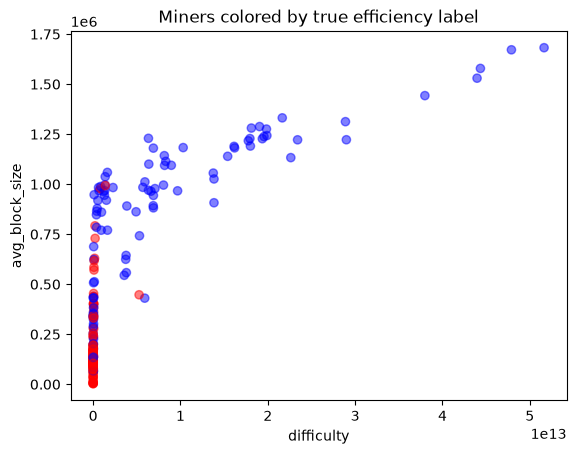

In [53]:
import matplotlib.pyplot as plt

plt.scatter(X_test_raw['difficulty'], X_test_raw['avg_block_size'], c=label_colors, alpha=0.5)
# plt.xscale('log')
# plt.yscale('log')
plt.xlabel('difficulty')
plt.ylabel('avg_block_size')
plt.title('Miners colored by true efficiency label')
plt.show()

C:\Users\KwokYenMing\AppData\Local\Temp\ipykernel_8672\2306184200.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


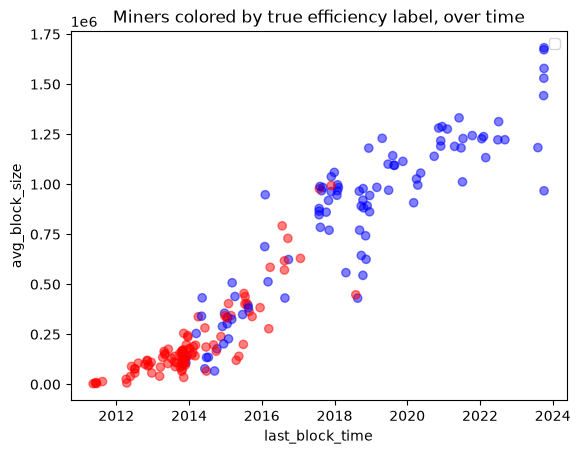

In [54]:
plt.scatter(X_test_raw['last_block_time'], X_test_raw['avg_block_size'], c=label_colors, alpha=0.5)
plt.xlabel('last_block_time')
plt.ylabel('avg_block_size')
plt.title('Miners colored by true efficiency label, over time')
plt.legend()
plt.show()

In [55]:
X_test_raw['mean_of_ratios_efficiency'].corr(X_test_raw['last_block_time'].astype('int64'))

np.float64(0.4956328081503338)

In [56]:
drop_features.sort_values('last_block_time')['label_mor'].reset_index(drop=True)

0      0
1      0
2      0
3      0
4      0
      ..
970    1
971    1
972    1
973    1
974    1
Name: label_mor, Length: 975, dtype: int64

In [57]:
sorted_labels = drop_features.sort_values('last_block_time')['label_mor'].reset_index(drop=True)
split_point = int(len(sorted_labels) * 0.8)

print("Train (earliest 80%):")
print(sorted_labels[:split_point].value_counts())

print("\nTest (most recent 20%):")
print(sorted_labels[split_point:].value_counts())

Train (earliest 80%):
label_mor
0    487
1    293
Name: count, dtype: int64

Test (most recent 20%):
label_mor
1    194
0      1
Name: count, dtype: int64


#### Quick Double Check if converting satoshi to BTC affects anything (it doesnt)

In [58]:
# --- Verify that satoshi vs BTC units don't change the efficiency labels ---
SATOSHIS_PER_BTC = 1e8

for name, df in [('bucket_features', bucket_features), ('drop_features', drop_features)]:

    # mean_of_ratios_efficiency was built from block_efficiency = transaction_count / total_output_satoshis
    # (satoshis). Multiplying by SATOSHIS_PER_BTC is equivalent to having divided by BTC-denominated
    # volume in the first place (linearity of mean survives a constant per-row scaling).
    eff_satoshi = df['mean_of_ratios_efficiency']
    eff_btc = eff_satoshi * SATOSHIS_PER_BTC

    labels_satoshi = (eff_satoshi > eff_satoshi.median()).astype(int)
    labels_btc = (eff_btc > eff_btc.median()).astype(int)

    print(f"{name} (mean_of_ratios): labels identical = {(labels_satoshi == labels_btc).all()}, "
          f"mismatches = {(labels_satoshi != labels_btc).sum()}")
    print(f"{name}: recomputed label matches stored label_mor = {(labels_satoshi == df['label_mor']).all()}")

    # same check for ratio_of_means_efficiency = avg_transactions / avg_volume (avg_volume in satoshis)
    rom_satoshi = df['ratio_of_means_efficiency']
    rom_btc = df['avg_transactions'] / ((df['avg_volume'] / SATOSHIS_PER_BTC) + 1e-9)

    labels_rom_satoshi = (rom_satoshi > rom_satoshi.median()).astype(int)
    labels_rom_btc = (rom_btc > rom_btc.median()).astype(int)

    print(f"{name} (ratio_of_means): labels identical = {(labels_rom_satoshi == labels_rom_btc).all()}\n")

bucket_features (mean_of_ratios): labels identical = True, mismatches = 0
bucket_features: recomputed label matches stored label_mor = True
bucket_features (ratio_of_means): labels identical = True

drop_features (mean_of_ratios): labels identical = True, mismatches = 0
drop_features: recomputed label matches stored label_mor = True
drop_features (ratio_of_means): labels identical = True



#### Getting Middle Timespan of each miner

In [59]:
# --- Span check: how long is each miner's active period? ---
# A miner's "span" = time between its first and last mined block.
# This tells us whether the first/last/midpoint timestamp choice even matters:
#   - if most spans are short, first ≈ last ≈ midpoint, so the choice is irrelevant
#   - if many spans are long, the choice matters and midpoint is worth using

miner_df = drop_features   # <-- rename to your actual per-miner dataframe

# span as a timedelta, then convert to days for readability
span = miner_df['last_block_time'] - miner_df['first_block_time']
span_days = span.dt.total_seconds() / 86400   # 86400 seconds in a day

# summary of the distribution
print("Span in days — distribution across miners:")
print(span_days.describe())

# a few extra percentiles the default .describe() doesn't show,
# because the tail is what tells us if long-span miners are common or rare
print("\nExtra percentiles (days):")
for q in [0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]:
    print(f"  {int(q*100)}th percentile: {span_days.quantile(q):.1f} days")

# how many miners span more than a year? (a rough "long-span" flag)
long_span = (span_days > 365).sum()
print(f"\nMiners spanning > 1 year: {long_span} of {len(span_days)} "
      f"({100*long_span/len(span_days):.1f}%)")

Span in days — distribution across miners:
count     975.000000
mean      196.236802
std       298.590366
min         0.540035
25%        32.413056
50%       111.344398
75%       262.233993
max      3805.907755
dtype: float64

Extra percentiles (days):
  10th percentile: 5.1 days
  25th percentile: 32.4 days
  50th percentile: 111.3 days
  75th percentile: 262.2 days
  90th percentile: 439.5 days
  95th percentile: 604.2 days
  99th percentile: 1321.5 days

Miners spanning > 1 year: 148 of 975 (15.2%)


In [60]:
# --- Sub-decision 1 resolved: represent each miner by the MIDPOINT of its active span ---
# 15.2% of miners span >1 year, so first/last would misplace long-lived miners.
# midpoint = first_block_time + half the span = the center of their active period.
miner_df['mid_block_time'] = miner_df['first_block_time'] + span / 2

# quick sanity check: midpoint should sit between first and last for every miner
assert (miner_df['mid_block_time'] >= miner_df['first_block_time']).all()
assert (miner_df['mid_block_time'] <= miner_df['last_block_time']).all()
print("mid_block_time created and verified to sit within each miner's span.")
print(miner_df[['first_block_time', 'mid_block_time', 'last_block_time']].head())

mid_block_time created and verified to sit within each miner's span.
           first_block_time                   mid_block_time  \
0 2013-12-07 04:40:06+00:00        2014-01-07 06:06:17+00:00   
1 2018-01-25 04:26:26+00:00 2018-02-05 14:24:05.500000+00:00   
2 2012-08-09 01:05:38+00:00        2012-09-22 22:06:37+00:00   
3 2020-02-25 16:19:17+00:00        2020-06-26 18:15:33+00:00   
4 2017-07-19 11:43:41+00:00 2018-03-26 01:38:36.500000+00:00   

            last_block_time  
0 2014-02-07 07:32:28+00:00  
1 2018-02-17 00:21:45+00:00  
2 2012-11-06 19:07:36+00:00  
3 2020-10-26 20:11:49+00:00  
4 2018-11-30 15:33:32+00:00  


In [61]:
# --- Sub-decision 2 check: how many miners fall in each calendar year? ---
# We bin miners by the YEAR of their midpoint, then count.
# A year with very few miners gives a noisy median (a median over 4 miners is
# basically luck), which would defeat the point of a "fair" contemporary comparison.

miner_df['mid_year'] = miner_df['mid_block_time'].dt.year

year_counts = miner_df['mid_year'].value_counts().sort_index()
print("Miners per midpoint-year:")
print(year_counts)

print(f"\nTotal years covered: {miner_df['mid_year'].nunique()}")
print(f"Total miners: {len(miner_df)}")
print(f"Smallest year count: {year_counts.min()} "
      f"(year {year_counts.idxmin()})")
print(f"Largest year count:  {year_counts.max()} "
      f"(year {year_counts.idxmax()})")

Miners per midpoint-year:
mid_year
2011     26
2012    100
2013    165
2014    212
2015    103
2016     24
2017     82
2018     69
2019     62
2020     45
2021     47
2022     20
2023     20
Name: count, dtype: int64

Total years covered: 13
Total miners: 975
Smallest year count: 20 (year 2022)
Largest year count:  212 (year 2014)


In [62]:
# --- Time-local relabel: compare each miner to its OWN year's median ---
# Old label: 1 if efficiency > median(ALL miners ever)  -> contaminated by time drift
# New label: 1 if efficiency > median(miners in the SAME year) -> drift removed

# transform('median') computes each year's median and broadcasts it back to every
# row in that year, so each miner gets its own year's median to compare against.
miner_df['year_median_eff'] = (
    miner_df.groupby('mid_year')['mean_of_ratios_efficiency'].transform('median')
)

# label 1 if the miner beats its own year's median, else 0
miner_df['label_timelocal'] = (
    miner_df['mean_of_ratios_efficiency'] > miner_df['year_median_eff']
).astype(int)

print("Time-local label created.")
print(miner_df['label_timelocal'].value_counts())

Time-local label created.
label_timelocal
0    490
1    485
Name: count, dtype: int64


In [63]:
# --- Did the time-local relabel actually remove the time contamination? ---
# Test 1: the NEW label should be ~50/50 WITHIN each year (that's what a per-year
#         median guarantees by construction). Confirms the mechanism did what we think.
print("Label balance within each year (should be ~50/50 every row):")
print(miner_df.groupby('mid_year')['label_timelocal'].value_counts().unstack(fill_value=0))

# Test 2: THE KEY ONE. Recreate §81.3's broken chronological 80/20 split, but with
#         the NEW label. Before, the test set was 194/195 one class. If the fix worked,
#         it should now be roughly balanced.
sorted_by_time = miner_df.sort_values('mid_block_time').reset_index(drop=True)
n = len(sorted_by_time)
split = int(n * 0.8)
train_labels = sorted_by_time.iloc[:split]['label_timelocal']
test_labels  = sorted_by_time.iloc[split:]['label_timelocal']

print("\n--- Chronological 80/20 split, NEW label ---")
print(f"Train (earliest 80%, n={len(train_labels)}): "
      f"{(train_labels==0).sum()} label-0 / {(train_labels==1).sum()} label-1")
print(f"Test  (latest 20%,  n={len(test_labels)}): "
      f"{(test_labels==0).sum()} label-0 / {(test_labels==1).sum()} label-1")

Label balance within each year (should be ~50/50 every row):
label_timelocal    0    1
mid_year                 
2011              13   13
2012              50   50
2013              83   82
2014             106  106
2015              52   51
2016              12   12
2017              41   41
2018              35   34
2019              31   31
2020              23   22
2021              24   23
2022              10   10
2023              10   10

--- Chronological 80/20 split, NEW label ---
Train (earliest 80%, n=780): 392 label-0 / 388 label-1
Test  (latest 20%,  n=195): 98 label-0 / 97 label-1


#### Rerun the Training with the new time-based median labelling

In [64]:
# --- Era-stratified test: train on earliest 80%, test on latest 20%, time-local label ---
# SAME pipeline as the 88.72% result (drop_features, real_fee reduced features,
# matched log transforms, same scaler, same MLPClassifier config).
# ONLY two things differ from that result:
#   (1) split is CHRONOLOGICAL (by mid_block_time), not random
#   (2) label is label_timelocal (year-local median), not label_mor (global median)

from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# 1. Apply the SAME feature transform used for the 88.72% result.
#    transform_skewed_features returns a copy, so this doesn't mutate drop_features.
era_df = transform_skewed_features(drop_features, 'real_fee')

# 2. Bring the time-local label + midpoint over from miner_df by index.
#    (drop_features and miner_df are the same rows, so .loc on the shared index aligns them.)
era_df['label_timelocal'] = miner_df.loc[era_df.index, 'label_timelocal']
era_df['mid_block_time']   = miner_df.loc[era_df.index, 'mid_block_time']

# 3. Sort chronologically by midpoint, then cut the earliest 80% / latest 20%.
era_df = era_df.sort_values('mid_block_time').reset_index(drop=True)
split = int(len(era_df) * 0.8)

feature_cols = feature_sets_reduced['real_fee']
X_train = era_df.iloc[:split][feature_cols]
X_test  = era_df.iloc[split:][feature_cols]
y_train = era_df.iloc[:split]['label_timelocal']
y_test  = era_df.iloc[split:]['label_timelocal']

# 4. Scale (fit on train only — same as before).
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# 5. Same model config as the 88.72% result.
era_model = MLPClassifier(
    hidden_layer_sizes=(64, 32, 16, 8), activation='relu', solver='adam',
    alpha=0.001, random_state=42, early_stopping=True,
    validation_fraction=0.1, n_iter_no_change=20, max_iter=100, batch_size=16
)
era_model.fit(X_train_scaled, y_train)

# 6. Results — with the baseline it MUST be read against.
era_test_acc = accuracy_score(y_test, era_model.predict(X_test_scaled))
majority_baseline = y_test.value_counts(normalize=True).max()

print(f"Test set size: {len(y_test)}")
print(f"Test label balance: {dict(y_test.value_counts())}")
print(f"Majority-class baseline (always guess most common): {majority_baseline:.4f}")
print("-----------")
print(f"Era-stratified test accuracy: {era_test_acc:.4f}")
print("-----------")
print("Confusion matrix [rows=true 0/1, cols=pred 0/1]:")
print(confusion_matrix(y_test, era_model.predict(X_test_scaled)))

Test set size: 195
Test label balance: {0: np.int64(98), 1: np.int64(97)}
Majority-class baseline (always guess most common): 0.5026
-----------
Era-stratified test accuracy: 0.5282
-----------
Confusion matrix [rows=true 0/1, cols=pred 0/1]:
[[14 84]
 [ 8 89]]


In [65]:
# --- Walk-forward (rolling-origin) validation, by year ---
# For each test year Y: train on all miners BEFORE Y, test on miners FROM Y.
# This only ever asks the model to predict ~1 year ahead, where feature scales and
# the feature->label relationship are close to the training data — a fair test of
# NEAR-TERM signal, unlike the single 2011->2023 leap that collapsed.
# Same pipeline as before: drop_features, real_fee reduced features, matched log
# transforms, same StandardScaler (fit per-fold on train only), same MLPClassifier.

from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Build the working frame: transformed features + time-local label + year.
# log1p is a fixed function (no fitting), so applying it once to the whole frame
# does NOT leak information across the split — only the SCALER is fit per-fold.
wf_df = transform_skewed_features(drop_features, 'real_fee')
wf_df['label_timelocal'] = miner_df.loc[wf_df.index, 'label_timelocal']
wf_df['mid_year']        = miner_df.loc[wf_df.index, 'mid_year']

feature_cols = feature_sets_reduced['real_fee']
all_years = sorted(wf_df['mid_year'].unique())

MIN_TRAIN = 100          # don't test a year until we have at least this many train miners
WINDOW = None            # None = expanding window; set to an int (e.g. 3) for sliding

wf_results = []
for test_year in all_years:
    # define the training window
    if WINDOW is None:
        train_mask = wf_df['mid_year'] < test_year                      # expanding
    else:
        train_mask = (wf_df['mid_year'] < test_year) & \
                     (wf_df['mid_year'] >= test_year - WINDOW)           # sliding
    test_mask = wf_df['mid_year'] == test_year

    n_train, n_test = train_mask.sum(), test_mask.sum()
    if n_train < MIN_TRAIN or n_test == 0:
        continue   # skip years with too little history or no test miners

    X_train = wf_df.loc[train_mask, feature_cols]
    X_test  = wf_df.loc[test_mask,  feature_cols]
    y_train = wf_df.loc[train_mask, 'label_timelocal']
    y_test  = wf_df.loc[test_mask,  'label_timelocal']

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)   # fit on THIS fold's train only
    X_test_scaled  = scaler.transform(X_test)

    model = MLPClassifier(
        hidden_layer_sizes=(64, 32, 16, 8), activation='relu', solver='adam',
        alpha=0.001, random_state=42, early_stopping=True,
        validation_fraction=0.1, n_iter_no_change=20, max_iter=100, batch_size=16
    )
    model.fit(X_train_scaled, y_train)

    acc = accuracy_score(y_test, model.predict(X_test_scaled))
    baseline = y_test.value_counts(normalize=True).max()   # per-year majority baseline

    wf_results.append({
        'test_year': test_year, 'n_train': int(n_train), 'n_test': int(n_test),
        'accuracy': round(acc, 4), 'baseline': round(baseline, 4),
        'lift': round(acc - baseline, 4)   # how much the model beats a coin-flip-ish guess
    })

wf_df_results = pd.DataFrame(wf_results)
print(wf_df_results.to_string(index=False))

# Overall summary, weighted by how many miners each test year contributes
w = wf_df_results['n_test']
overall_acc      = (wf_df_results['accuracy'] * w).sum() / w.sum()
overall_baseline = (wf_df_results['baseline'] * w).sum() / w.sum()
print(f"\nWeighted overall accuracy: {overall_acc:.4f}")
print(f"Weighted overall baseline: {overall_baseline:.4f}")
print(f"Weighted overall lift:     {overall_acc - overall_baseline:+.4f}")

 test_year  n_train  n_test  accuracy  baseline    lift
      2013      126     165    0.4970    0.5030 -0.0061
      2014      291     212    0.4292    0.5000 -0.0708
      2015      503     103    0.4757    0.5049 -0.0291
      2016      606      24    0.5000    0.5000  0.0000
      2017      630      82    0.5122    0.5000  0.0122
      2018      712      69    0.3043    0.5072 -0.2029
      2019      781      62    0.4677    0.5000 -0.0323
      2020      843      45    0.4889    0.5111 -0.0222
      2021      888      47    0.3617    0.5106 -0.1489
      2022      935      20    0.6000    0.5000  0.1000
      2023      955      20    0.5500    0.5000  0.0500

Weighted overall accuracy: 0.4570
Weighted overall baseline: 0.5029
Weighted overall lift:     -0.0459


In [66]:
# --- Walk-forward (rolling-origin) validation, by year ---
# For each test year Y: train on all miners BEFORE Y, test on miners FROM Y.
# This only ever asks the model to predict ~1 year ahead, where feature scales and
# the feature->label relationship are close to the training data — a fair test of
# NEAR-TERM signal, unlike the single 2011->2023 leap that collapsed.
# Same pipeline as before: drop_features, real_fee reduced features, matched log
# transforms, same StandardScaler (fit per-fold on train only), same MLPClassifier.

from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Build the working frame: transformed features + time-local label + year.
# log1p is a fixed function (no fitting), so applying it once to the whole frame
# does NOT leak information across the split — only the SCALER is fit per-fold.
wf_df = transform_skewed_features(drop_features, 'real_fee')
wf_df['label_timelocal'] = miner_df.loc[wf_df.index, 'label_timelocal']
wf_df['mid_year']        = miner_df.loc[wf_df.index, 'mid_year']

feature_cols = feature_sets_reduced['real_fee']
all_years = sorted(wf_df['mid_year'].unique())

MIN_TRAIN = 100          # don't test a year until we have at least this many train miners
WINDOW = 3            # None = expanding window; set to an int (e.g. 3) for sliding

wf_results = []
for test_year in all_years:
    # define the training window
    if WINDOW is None:
        train_mask = wf_df['mid_year'] < test_year                      # expanding
    else:
        train_mask = (wf_df['mid_year'] < test_year) & \
                     (wf_df['mid_year'] >= test_year - WINDOW)           # sliding
    test_mask = wf_df['mid_year'] == test_year

    n_train, n_test = train_mask.sum(), test_mask.sum()
    if n_train < MIN_TRAIN or n_test == 0:
        continue   # skip years with too little history or no test miners

    X_train = wf_df.loc[train_mask, feature_cols]
    X_test  = wf_df.loc[test_mask,  feature_cols]
    y_train = wf_df.loc[train_mask, 'label_timelocal']
    y_test  = wf_df.loc[test_mask,  'label_timelocal']

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)   # fit on THIS fold's train only
    X_test_scaled  = scaler.transform(X_test)

    model = MLPClassifier(
        hidden_layer_sizes=(64, 32, 16, 8), activation='relu', solver='adam',
        alpha=0.001, random_state=42, early_stopping=True,
        validation_fraction=0.1, n_iter_no_change=20, max_iter=100, batch_size=16
    )
    model.fit(X_train_scaled, y_train)

    acc = accuracy_score(y_test, model.predict(X_test_scaled))
    baseline = y_test.value_counts(normalize=True).max()   # per-year majority baseline

    wf_results.append({
        'test_year': test_year, 'n_train': int(n_train), 'n_test': int(n_test),
        'accuracy': round(acc, 4), 'baseline': round(baseline, 4),
        'lift': round(acc - baseline, 4)   # how much the model beats a coin-flip-ish guess
    })

wf_df_results = pd.DataFrame(wf_results)
print(wf_df_results.to_string(index=False))

# Overall summary, weighted by how many miners each test year contributes
w = wf_df_results['n_test']
overall_acc      = (wf_df_results['accuracy'] * w).sum() / w.sum()
overall_baseline = (wf_df_results['baseline'] * w).sum() / w.sum()
print(f"\nWeighted overall accuracy: {overall_acc:.4f}")
print(f"Weighted overall baseline: {overall_baseline:.4f}")
print(f"Weighted overall lift:     {overall_acc - overall_baseline:+.4f}")

 test_year  n_train  n_test  accuracy  baseline    lift
      2013      126     165    0.4970    0.5030 -0.0061
      2014      291     212    0.4292    0.5000 -0.0708
      2015      477     103    0.5340    0.5049  0.0291
      2016      480      24    0.4583    0.5000 -0.0417
      2017      339      82    0.5366    0.5000  0.0366
      2018      209      69    0.3188    0.5072 -0.1884
      2019      175      62    0.4839    0.5000 -0.0161
      2020      213      45    0.4889    0.5111 -0.0222
      2021      176      47    0.4043    0.5106 -0.1064
      2022      154      20    0.5000    0.5000  0.0000
      2023      112      20    0.6500    0.5000  0.1500

Weighted overall accuracy: 0.4700
Weighted overall baseline: 0.5029
Weighted overall lift:     -0.0330


In [67]:
# --- Persistence test: is a miner's efficiency stable across its own lifetime? ---
# Splits each miner's blocks chronologically into first half / second half,
# computes mean_of_ratios efficiency separately on each, then asks whether
# miners keep their relative ranking between the two halves.

from scipy.stats import spearmanr


def split_halves(data, min_blocks, group_col='miner_group'):
    """Return a frame of one row per miner: efficiency in first half vs second half."""
    df = data[data[group_col] != 'long_tail'].copy()

    # keep only miners with enough blocks for both halves to be meaningful
    counts = df[group_col].value_counts()
    df = df[df[group_col].isin(counts[counts >= min_blocks].index)].copy()

    # per-block efficiency — identical definition to build_miner_features
    df['block_efficiency'] = df['transaction_count'] / df['total_output_satoshis']

    # chronological order WITHIN each miner.
    # block_number (height) not timestamp: block timestamps are miner-declared
    # and can run slightly out of order; height is strictly sequential.
    df = df.sort_values([group_col, 'block_number'])

    # cumcount numbers each miner's blocks 0,1,2,... within its own group.
    # Comparing that against half the miner's total gives a first/second flag
    # in one vectorised operation (odd counts put the middle block in 'second').
    df['pos']      = df.groupby(group_col).cumcount()
    df['n_blocks'] = df.groupby(group_col)['block_number'].transform('size')
    df['half']     = np.where(df['pos'] < df['n_blocks'] // 2, 'first', 'second')

    # mean_of_ratios efficiency, computed separately per half
    halves = (df.groupby([group_col, 'half'])['block_efficiency']
                .mean()
                .unstack())

    return halves.dropna()


def persistence_stats(halves):
    """Spearman rank correlation + binary label agreement between the two halves."""
    rho, pval = spearmanr(halves['first'], halves['second'])

    # binary version: median-split EACH half on its own, then check whether
    # a miner lands in the same class both times. Directly comparable to the
    # accuracy figures in section 83.
    lab_first  = (halves['first']  > halves['first'].median()).astype(int)
    lab_second = (halves['second'] > halves['second'].median()).astype(int)
    agreement  = (lab_first == lab_second).mean()

    return {'n_miners': len(halves), 'spearman': rho,
            'p_value': pval, 'binary_agreement': agreement}


# --- sweep thresholds: the TREND across rows is the diagnostic ---
results = []
for min_blocks in [20, 30, 50, 100]:
    halves = split_halves(merged_df, min_blocks)
    stats  = persistence_stats(halves)
    stats['min_blocks'] = min_blocks
    results.append(stats)

persistence_df = pd.DataFrame(results)[
    ['min_blocks', 'n_miners', 'spearman', 'p_value', 'binary_agreement']
]
persistence_df.round(4)

,min_blocks,n_miners,spearman,p_value,binary_agreement
0,20,647,0.9203,0.0,0.8609
1,30,537,0.9211,0.0,0.8734
2,50,430,0.9249,0.0,0.8930
3,100,317,0.9227,0.0,0.9054


In [68]:
# --- Persistence test, TIME-CORRECTED ---
# Same as before, but each block's efficiency is first converted to a percentile
# rank among blocks mined in the SAME time window. This strips out era entirely:
# what survives is "was this block better than others mined around the same time."

def split_halves_generic(data, min_blocks, value_col, group_col='miner_group'):
    """Per-miner first-half vs second-half mean of `value_col`."""
    df = data[data[group_col] != 'long_tail'].copy()
    counts = df[group_col].value_counts()
    df = df[df[group_col].isin(counts[counts >= min_blocks].index)].copy()

    df = df.sort_values([group_col, 'block_number'])
    df['pos']      = df.groupby(group_col).cumcount()
    df['n_blocks'] = df.groupby(group_col)['block_number'].transform('size')
    df['half']     = np.where(df['pos'] < df['n_blocks'] // 2, 'first', 'second')

    return df.groupby([group_col, 'half'])[value_col].mean().unstack().dropna()


# Build the percentile columns ONCE, on the full dataset.
# Ranking against ALL blocks (long_tail included) is deliberate: the reference
# population is "everything mined at that time", not just tracked miners.
work = merged_df.copy()
work['timestamp']        = pd.to_datetime(work['timestamp'])
work['block_efficiency'] = work['transaction_count'] / work['total_output_satoshis']

work['year']  = work['timestamp'].dt.to_period('Y')
work['month'] = work['timestamp'].dt.to_period('M')

work['eff_pct_year']  = work.groupby('year')['block_efficiency'].rank(pct=True)
work['eff_pct_month'] = work.groupby('month')['block_efficiency'].rank(pct=True)

rows = []
for min_blocks in [20, 30, 50, 100]:
    row = {'min_blocks': min_blocks}
    for label, col in [('raw',   'block_efficiency'),
                       ('year',  'eff_pct_year'),
                       ('month', 'eff_pct_month')]:
        halves = split_halves_generic(work, min_blocks, col)
        rho, _ = spearmanr(halves['first'], halves['second'])
        lab_f  = (halves['first']  > halves['first'].median()).astype(int)
        lab_s  = (halves['second'] > halves['second'].median()).astype(int)
        row[f'rho_{label}']   = rho
        row[f'agree_{label}'] = (lab_f == lab_s).mean()
        row['n_miners']       = len(halves)
    rows.append(row)

corrected_df = pd.DataFrame(rows)[
    ['min_blocks', 'n_miners',
     'rho_raw', 'rho_year', 'rho_month',
     'agree_raw', 'agree_year', 'agree_month']
]
corrected_df.round(4)

C:\Users\KwokYenMing\AppData\Local\Temp\ipykernel_8672\2636063968.py:27: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  work['year']  = work['timestamp'].dt.to_period('Y')
C:\Users\KwokYenMing\AppData\Local\Temp\ipykernel_8672\2636063968.py:28: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  work['month'] = work['timestamp'].dt.to_period('M')


,min_blocks,n_miners,rho_raw,rho_year,rho_month,agree_raw,agree_year,agree_month
0,20,647,0.9203,0.2752,0.2452,0.8609,0.5889,0.5765
1,30,537,0.9211,0.3242,0.3020,0.8734,0.6015,0.5940
2,50,430,0.9249,0.3031,0.3199,0.8930,0.5814,0.6000
3,100,317,0.9227,0.2686,0.2993,0.9054,0.5584,0.5836


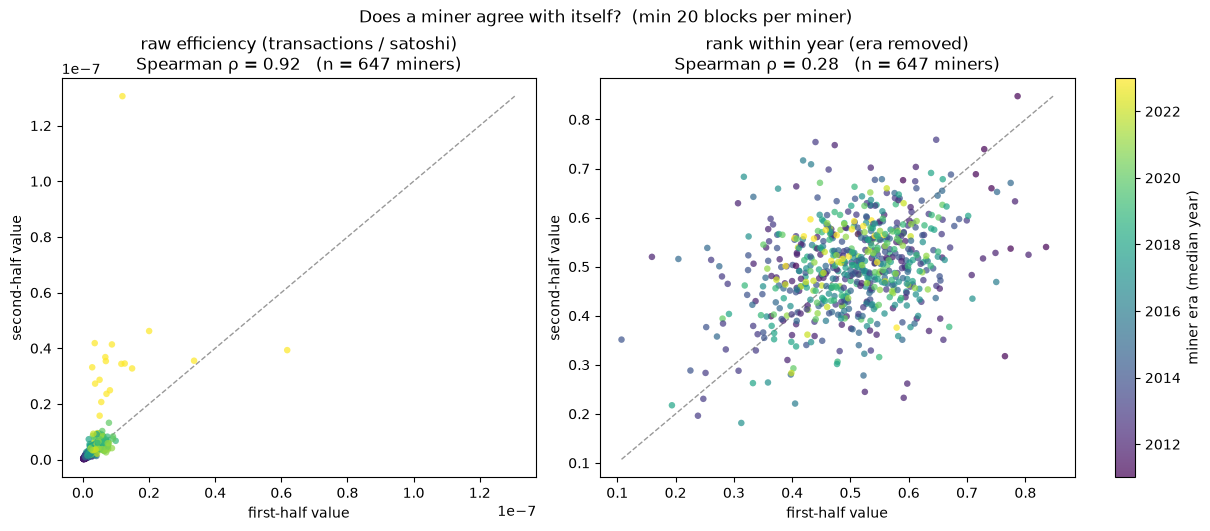

In [69]:
# --- Visualise split-half persistence: one dot = one miner ---
# x = its mean over its FIRST half of blocks, y = its SECOND half.
# Colour = the miner's era, so you can see why raw looks tidy and corrected doesn't.

MIN_BLOCKS = 20                         # same sweep values as the table: 20 / 30 / 50 / 100
work['year_num'] = work['timestamp'].dt.year
miner_era = work.groupby('miner_group')['year_num'].median()   # one representative year per miner

panels = [
    ('raw efficiency (transactions / satoshi)', 'block_efficiency'),
    ('rank within year (era removed)',          'eff_pct_year'),   # swap to 'eff_pct_month' for the monthly version
]

fig, axes = plt.subplots(1, len(panels), figsize=(12, 5.2), constrained_layout=True)

for ax, (title, col) in zip(axes, panels):
    halves = split_halves_generic(work, MIN_BLOCKS, col)
    eras   = miner_era.reindex(halves.index)                   # era of each surviving miner
    rho, _ = spearmanr(halves['first'], halves['second'])

    sc = ax.scatter(halves['first'], halves['second'],
                    c=eras, cmap='viridis', s=22, alpha=0.7, edgecolor='none')

    lo = min(halves['first'].min(), halves['second'].min())    # y = x reference line
    hi = max(halves['first'].max(), halves['second'].max())
    ax.plot([lo, hi], [lo, hi], color='0.6', ls='--', lw=1, zorder=0)

    ax.set_title(f"{title}\nSpearman ρ = {rho:.2f}   (n = {len(halves)} miners)")
    ax.set_xlabel('first-half value')
    ax.set_ylabel('second-half value')

cbar = fig.colorbar(sc, ax=axes, fraction=0.046, pad=0.04)
cbar.set_label('miner era (median year)')
fig.suptitle(f'Does a miner agree with itself?  (min {MIN_BLOCKS} blocks per miner)')
plt.show()

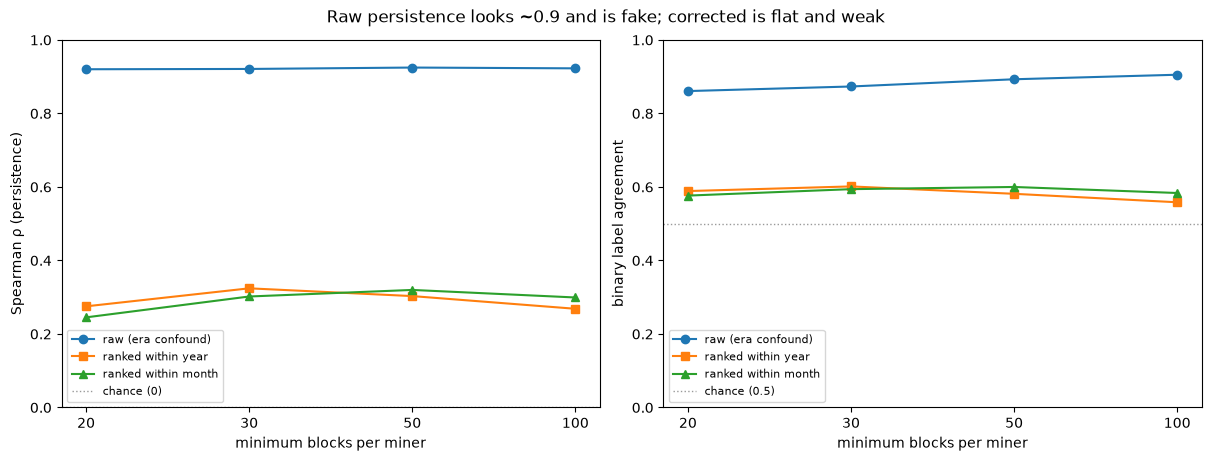

In [70]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
x = corrected_df['min_blocks'].astype(str)

for ax, metric, ylab, chance in [(ax1, 'rho',   'Spearman ρ (persistence)', 0.0),
                                 (ax2, 'agree', 'binary label agreement',   0.5)]:
    ax.plot(x, corrected_df[f'{metric}_raw'],   'o-', label='raw (era confound)')
    ax.plot(x, corrected_df[f'{metric}_year'],  's-', label='ranked within year')
    ax.plot(x, corrected_df[f'{metric}_month'], '^-', label='ranked within month')
    ax.axhline(chance, color='0.6', ls=':', lw=1, label=f'chance ({chance:g})')
    ax.set_xlabel('minimum blocks per miner')
    ax.set_ylabel(ylab)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)

fig.suptitle('Raw persistence looks ~0.9 and is fake; corrected is flat and weak')
plt.show()

#### Check n transactions and transaction volume across time

In [14]:
# 1. Make sure timestamp is an actual datetime, and set it as index
bitcoin_blocks['timestamp'] = pd.to_datetime(bitcoin_blocks['timestamp'])
monthly_blocks = bitcoin_blocks.set_index('timestamp')

# 2. Resample AND aggregate in one go — .mean() tells pandas what to do with each month's rows
monthly_avg = monthly_blocks.resample('ME')[['transaction_count', 'total_output_satoshis']].mean()

monthly_avg

,transaction_count,total_output_satoshis
timestamp,,
2009-01-31 00:00:00+00:00,1.012579,5.260024e+09
2009-02-28 00:00:00+00:00,1.010947,5.361969e+09
2009-03-31 00:00:00+00:00,1.006059,5.367859e+09
2009-04-30 00:00:00+00:00,1.004939,5.300189e+09
2009-05-31 00:00:00+00:00,1.005321,5.201299e+09
...,...,...
2023-06-30 00:00:00+00:00,2816.411083,7.188296e+11
2023-07-31 00:00:00+00:00,3139.903799,5.406648e+11
2023-08-31 00:00:00+00:00,3188.241539,5.662450e+11


In [26]:
monthly_avg['total_output_satoshis'].describe()

count    1.780000e+02
mean     1.039716e+12
std      9.521095e+11
min      5.196511e+09
25%      4.635119e+11
50%      7.948234e+11
75%      1.393087e+12
max      7.192113e+12
Name: total_output_satoshis, dtype: float64

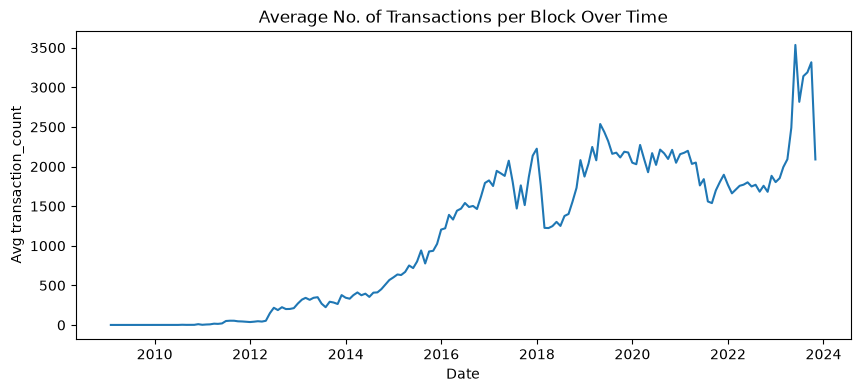

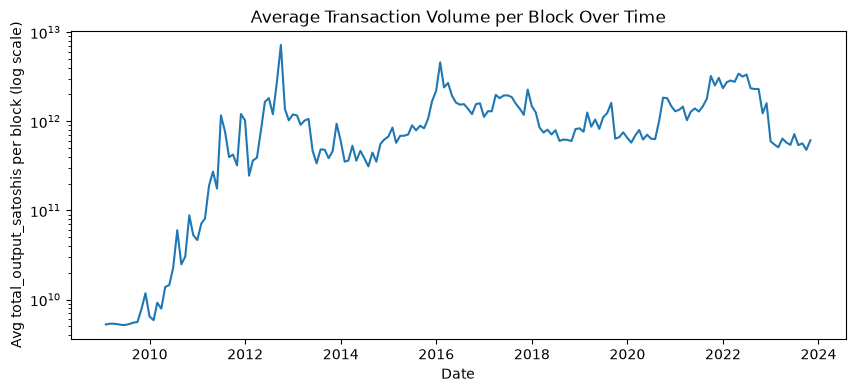

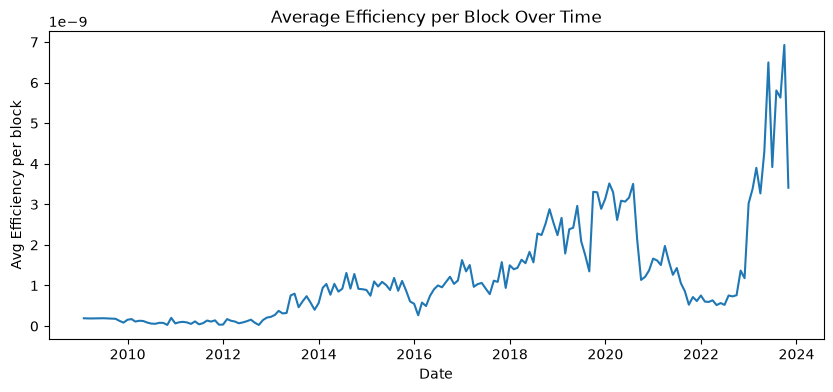

In [32]:
import matplotlib.pyplot as plt

# 1. no. of transactions per block over time
plt.figure(figsize=(10, 4))
plt.plot(monthly_avg.index, monthly_avg['transaction_count'])
plt.title('Average No. of Transactions per Block Over Time')
plt.xlabel('Date')
plt.ylabel('Avg transaction_count')
plt.show()

# 2. transaction volume per block over time
plt.figure(figsize=(10, 4))
plt.plot(monthly_avg.index, monthly_avg['total_output_satoshis'])
plt.yscale('log')  # volume spans many orders of magnitude, log scale keeps early years visible
plt.title('Average Transaction Volume per Block Over Time')
plt.xlabel('Date')
plt.ylabel('Avg total_output_satoshis per block (log scale)')
plt.show()

# 3. efficiency per block over time
plt.figure(figsize=(10, 4))
plt.plot(monthly_avg.index, monthly_avg['transaction_count'] / monthly_avg['total_output_satoshis'])
plt.title('Average Efficiency per Block Over Time')
plt.xlabel('Date')
plt.ylabel('Avg Efficiency per block')
plt.show()

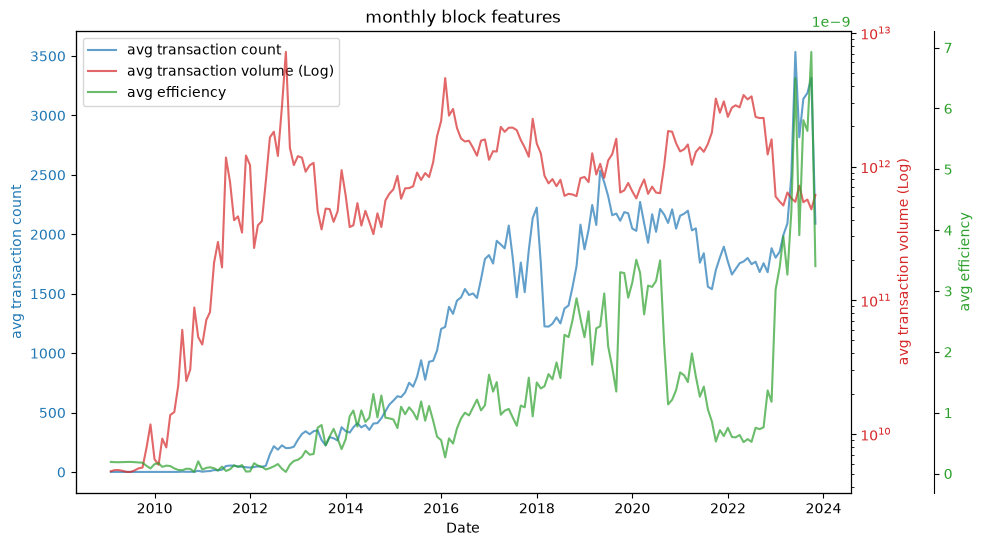

In [66]:
x  = monthly_avg.index
y1 = monthly_avg['transaction_count']
y2 = monthly_avg['total_output_satoshis']
y3 = monthly_avg['transaction_count'] / monthly_avg['total_output_satoshis']

# 1. Create the base figure and the first axis
fig, ax1 = plt.subplots(figsize=(10, 6))

# 2. Create twin axes for the second and third variables
ax2 = ax1.twinx()
ax3 = ax1.twinx()

# 3. Offset the right spine of the third axis to make room
ax3.spines['right'].set_position(('outward', 60))

# 4. Set log scale specifically for the second y-axis
ax2.set_yscale('log')

# 5. Plot the three lines with distinct colors
alpha_value = 0.7
p1, = ax1.plot(x, y1, color='tab:blue' , alpha=alpha_value, label='avg transaction count')
p2, = ax2.plot(x, y2, color='tab:red'  , alpha=alpha_value, label='avg transaction volume (Log)')
p3, = ax3.plot(x, y3, color='tab:green', alpha=alpha_value, label='avg efficiency')

# 6. Set labels and matching text colors for clarity
ax1.set_xlabel('Date')
ax1.set_ylabel('avg transaction count', color='tab:blue')
ax2.set_ylabel('avg transaction volume (Log)', color='tab:red')
ax3.set_ylabel('avg efficiency', color='tab:green')

# Tick styling to match line colors
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:red')
ax3.tick_params(axis='y', labelcolor='tab:green')

# 8. Consolidate legends from all axes into one box
lines = [p1, p2, p3]
ax1.legend(lines, [l.get_label() for l in lines], loc='upper left')

plt.title('monthly block features')
plt.show()

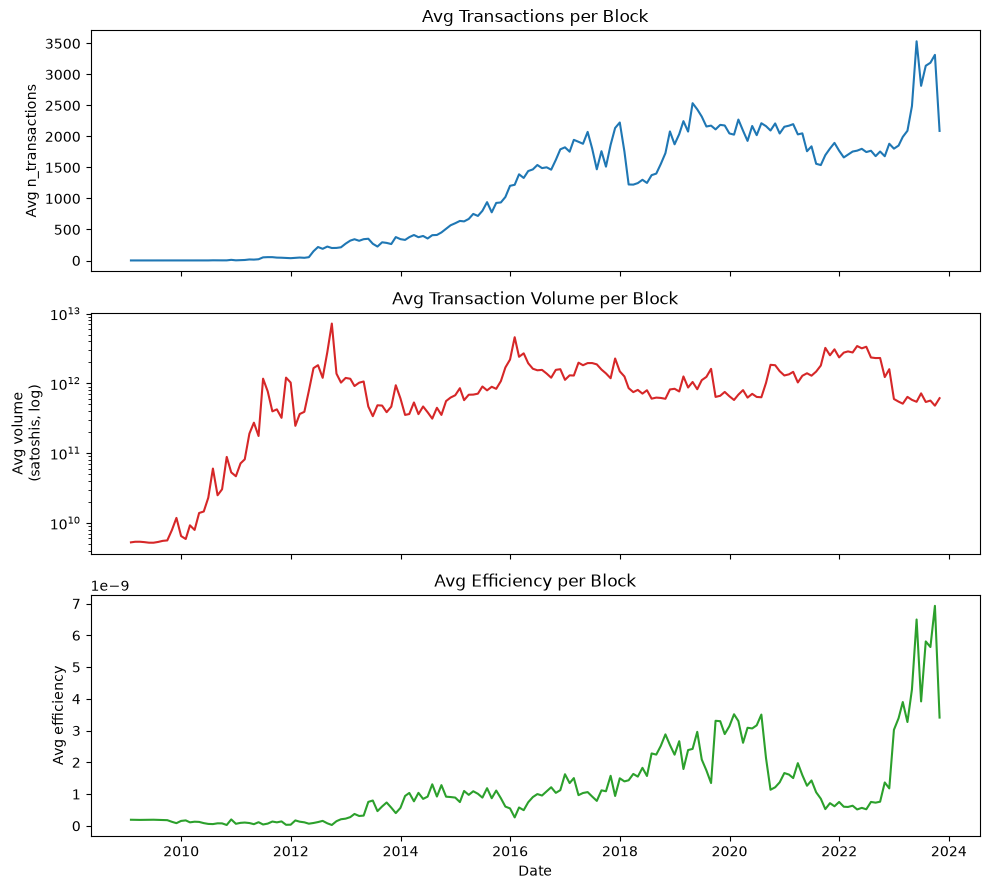

In [67]:
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

axes[0].plot(x, y1, color='tab:blue')
axes[0].set_ylabel('Avg n_transactions')
axes[0].set_title('Avg Transactions per Block')

axes[1].plot(x, y2, color='tab:red')
axes[1].set_yscale('log')
axes[1].set_ylabel('Avg volume\n(satoshis, log)')
axes[1].set_title('Avg Transaction Volume per Block')

axes[2].plot(x, y3, color='tab:green')
axes[2].set_ylabel('Avg efficiency')
axes[2].set_title('Avg Efficiency per Block')
axes[2].set_xlabel('Date')

plt.tight_layout()
plt.show()

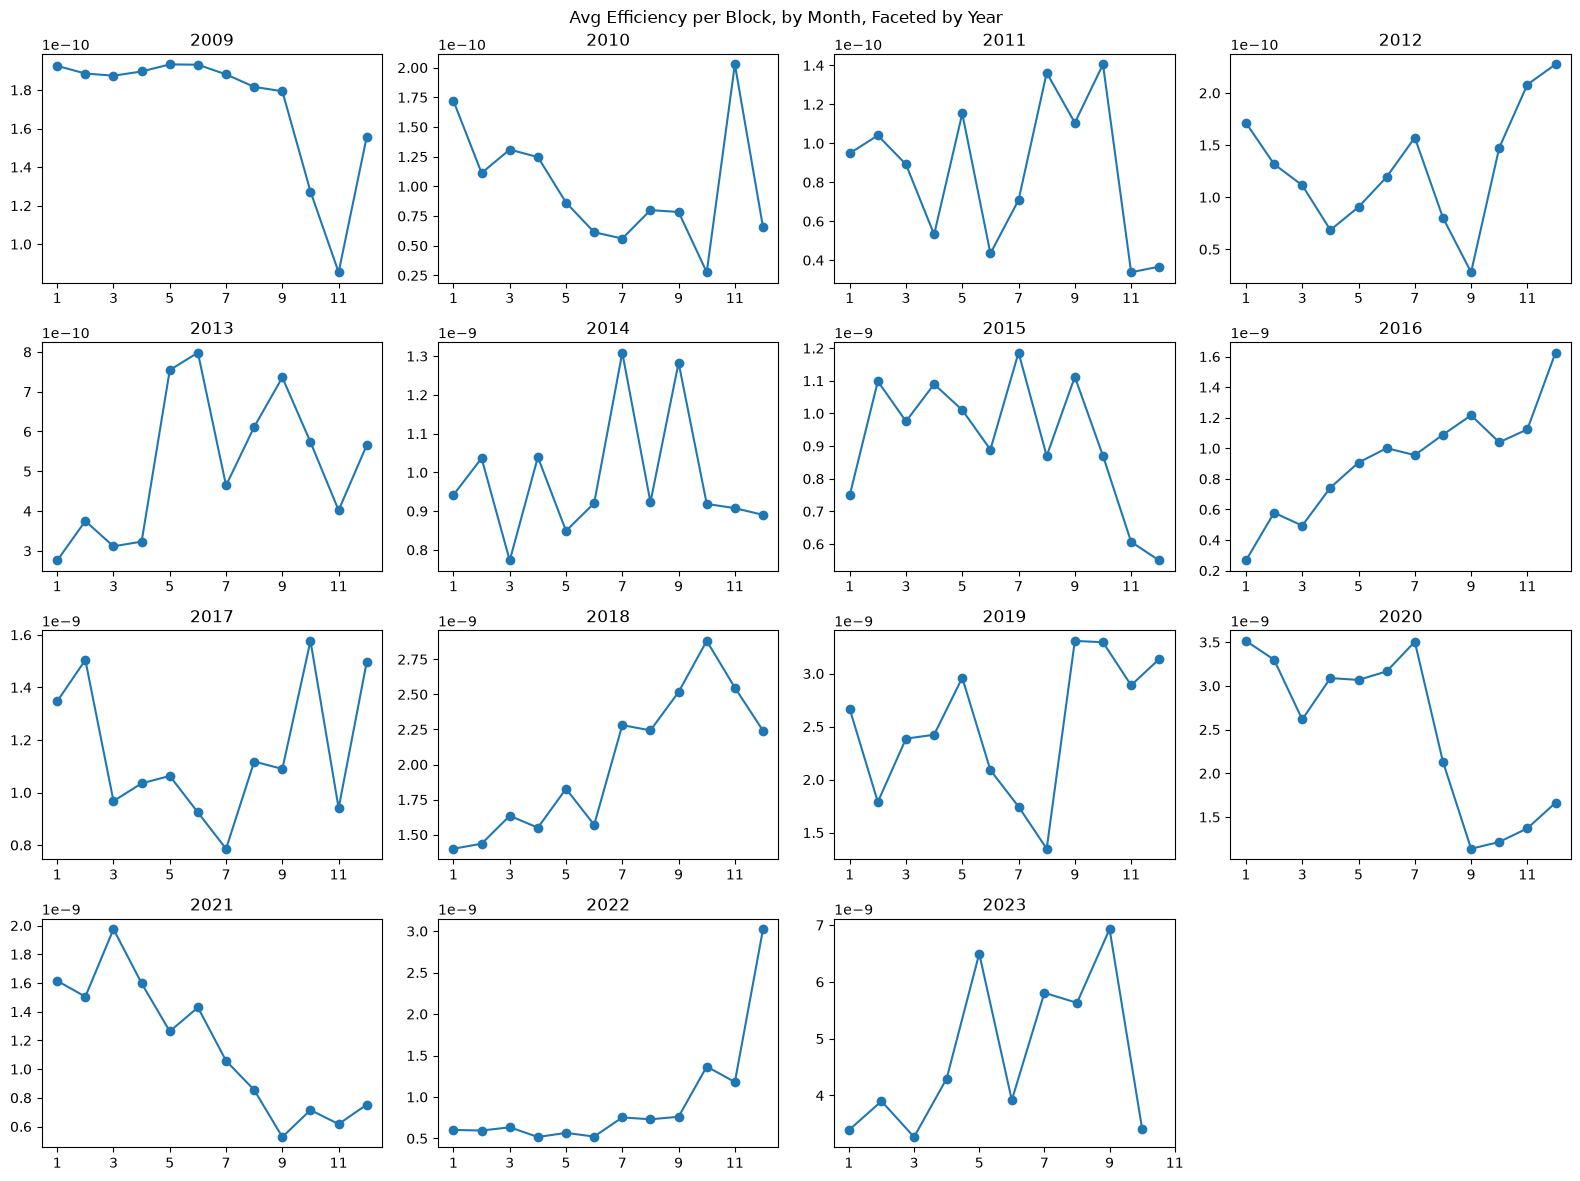

In [68]:
# Efficiency per block, computed once
monthly_avg['efficiency'] = monthly_avg['transaction_count'] / monthly_avg['total_output_satoshis']
monthly_avg['year'] = monthly_avg.index.year
monthly_avg['month'] = monthly_avg.index.month

years = sorted(monthly_avg['year'].unique())
n_years = len(years)
ncols = 4
nrows = -(-n_years // ncols)  # ceiling division, so we have enough panels

fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows), sharey=False)
axes = axes.flatten()

for i, yr in enumerate(years):
    yr_data = monthly_avg[monthly_avg['year'] == yr]
    axes[i].plot(yr_data['month'], yr_data['efficiency'], marker='o')
    axes[i].set_title(str(yr))
    axes[i].set_xticks(range(1, 13, 2))

# hide any leftover empty panels
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

fig.suptitle('Avg Efficiency per Block, by Month, Faceted by Year')
plt.tight_layout()
plt.show()

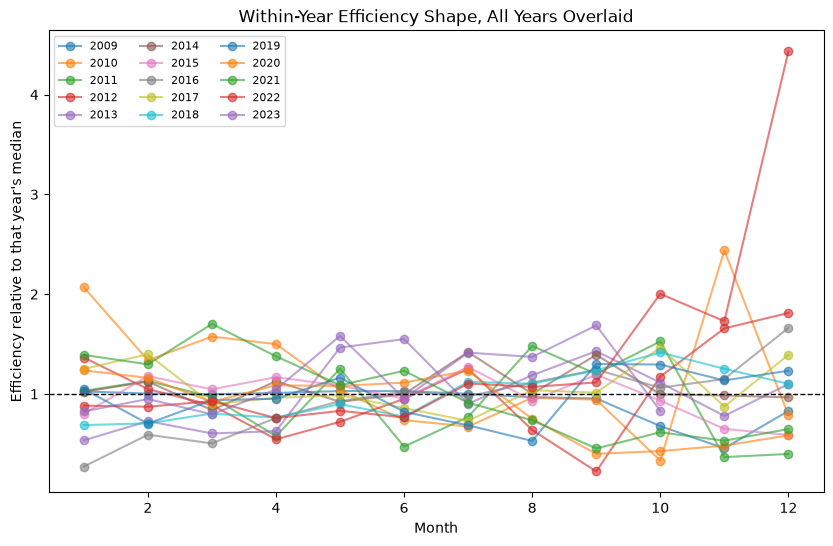

In [69]:
monthly_avg['eff_relative'] = monthly_avg['efficiency'] / monthly_avg.groupby('year')['efficiency'].transform('median')

plt.figure(figsize=(10, 6))
for yr in years:
    yr_data = monthly_avg[monthly_avg['year'] == yr]
    plt.plot(yr_data['month'], yr_data['eff_relative'], marker='o', alpha=0.6, label=str(yr))

plt.axhline(1.0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Month')
plt.ylabel('Efficiency relative to that year\'s median')
plt.title('Within-Year Efficiency Shape, All Years Overlaid')
plt.legend(ncol=3, fontsize=8)
plt.show()

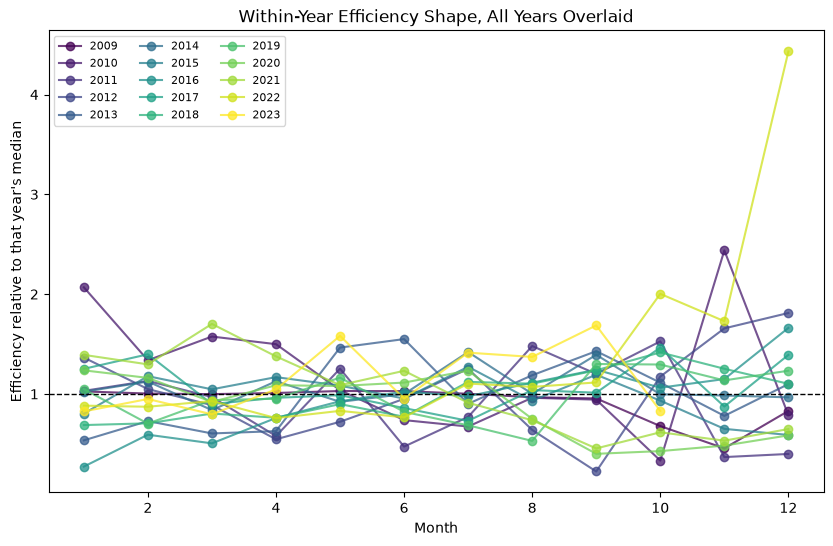

In [70]:
import numpy as np

colors = plt.cm.viridis(np.linspace(0, 1, len(years)))

fig, ax = plt.subplots(figsize=(10, 6))
for yr, c in zip(years, colors):
    yr_data = monthly_avg[monthly_avg['year'] == yr]
    ax.plot(yr_data['month'], yr_data['eff_relative'], marker='o',
            color=c, alpha=0.75, linewidth=1.5, label=str(yr))

ax.axhline(1.0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Month')
ax.set_ylabel("Efficiency relative to that year's median")
ax.set_title('Within-Year Efficiency Shape, All Years Overlaid')
ax.legend(ncol=3, fontsize=8)
plt.show()

In [71]:
monthly_avg = monthly_avg.copy()
monthly_avg['eff_relative'] = monthly_avg['efficiency'] / monthly_avg.groupby('year')['efficiency'].transform('median')

# The actual verification — no colour-reading involved
print(monthly_avg.nlargest(5, 'eff_relative')[['year', 'month', 'efficiency', 'eff_relative']])
print(monthly_avg.nsmallest(5, 'eff_relative')[['year', 'month', 'efficiency', 'eff_relative']])

# And the within-year spread number that's currently an eyeball estimate in §87.5
print(monthly_avg['eff_relative'].describe())

                           year  month    efficiency  eff_relative
timestamp                                                         
2022-12-31 00:00:00+00:00  2022     12  3.024169e-09      4.431225
2010-11-30 00:00:00+00:00  2010     11  2.027571e-10      2.437941
2010-01-31 00:00:00+00:00  2010      1  1.720423e-10      2.068627
2022-10-31 00:00:00+00:00  2022     10  1.367036e-09      2.003077
2012-12-31 00:00:00+00:00  2012     12  2.274260e-10      1.811144
                           year  month    efficiency  eff_relative
timestamp                                                         
2012-09-30 00:00:00+00:00  2012      9  2.801688e-11      0.223117
2016-01-31 00:00:00+00:00  2016      1  2.662110e-10      0.272122
2010-10-31 00:00:00+00:00  2010     10  2.764626e-11      0.332417
2011-11-30 00:00:00+00:00  2011     11  3.382338e-11      0.367571
2011-12-31 00:00:00+00:00  2011     12  3.670484e-11      0.398885
count    178.000000
mean       1.031882
std        0.431521
mi

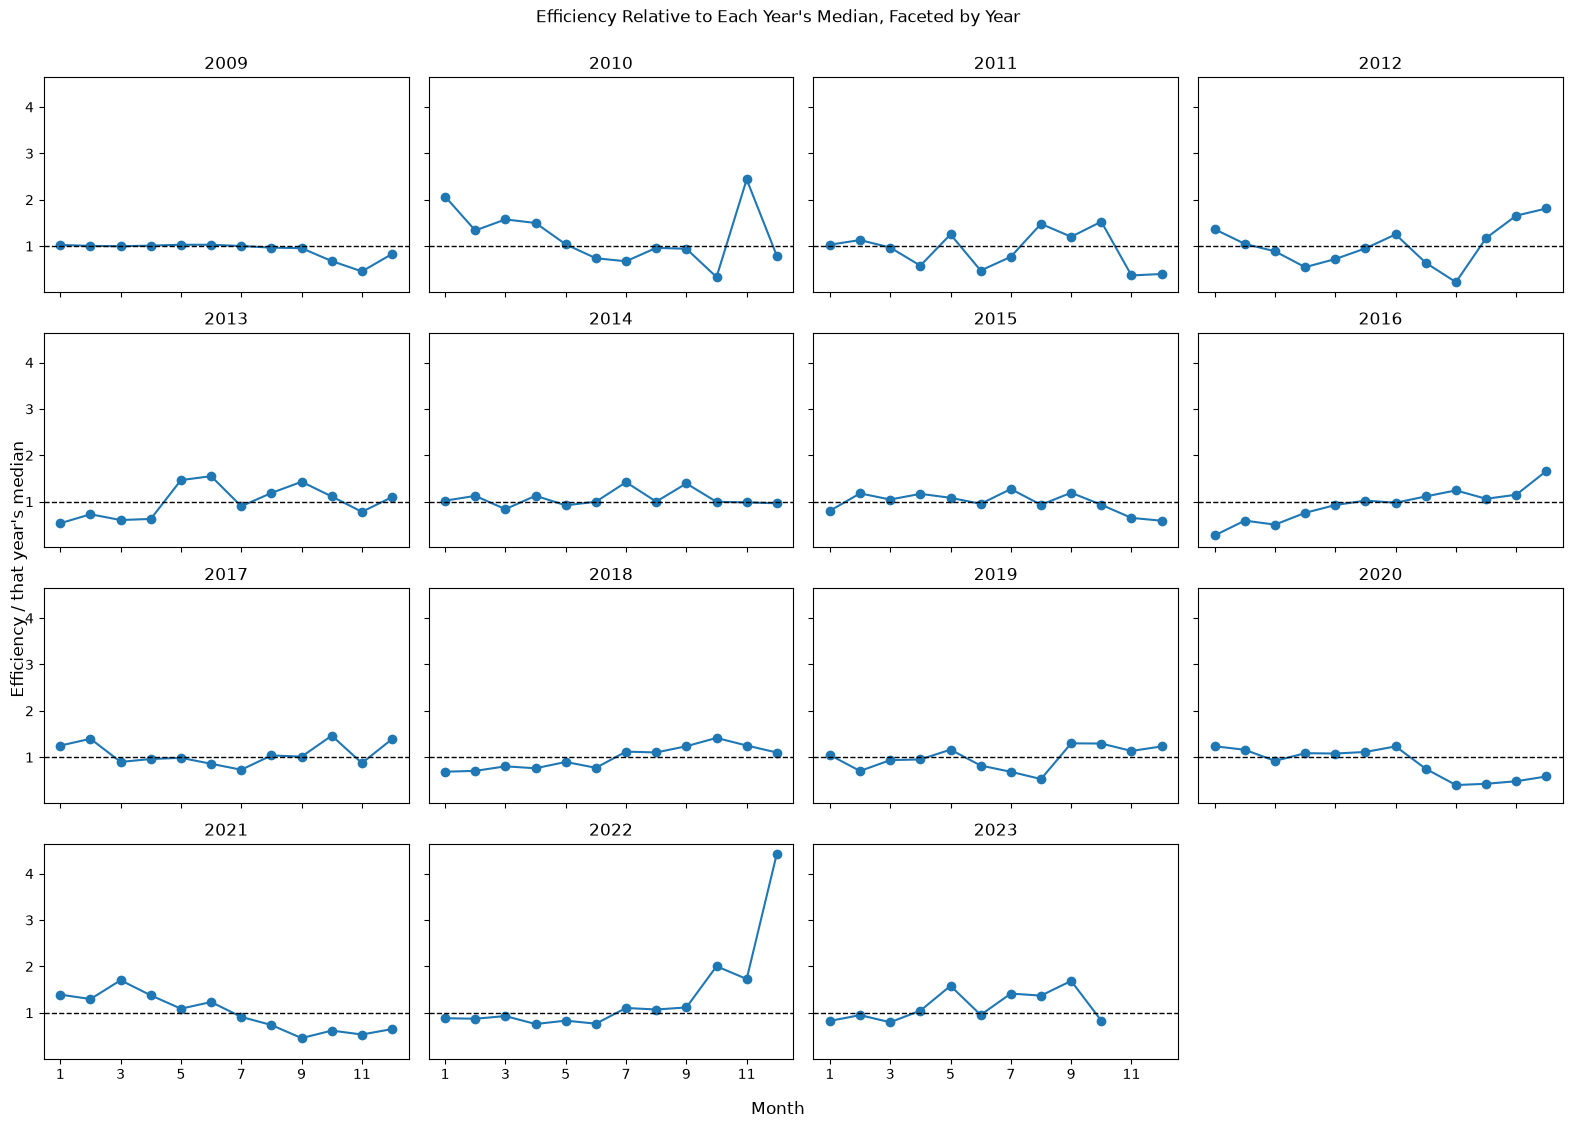

In [72]:
years = sorted(monthly_avg['year'].unique())
ncols = 4
nrows = -(-len(years) // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 2.8*nrows), sharey=True, sharex=True)
axes = axes.flatten()

for i, yr in enumerate(years):
    yr_data = monthly_avg[monthly_avg['year'] == yr].sort_values('month')
    axes[i].plot(yr_data['month'], yr_data['eff_relative'], marker='o', color='tab:blue')
    axes[i].axhline(1.0, color='black', linestyle='--', linewidth=1)
    axes[i].set_title(str(yr))
    axes[i].set_xticks(range(1, 13, 2))

for j in range(len(years), len(axes)):
    axes[j].axis('off')

fig.suptitle("Efficiency Relative to Each Year's Median, Faceted by Year", y=1.0)
fig.supxlabel('Month')
fig.supylabel("Efficiency / that year's median")
plt.tight_layout()
plt.show()

In [73]:
eff = monthly_avg['efficiency']

# 1. When does efficiency exceed everything that came before it?
running_max = eff.cummax()
new_highs = monthly_avg[eff >= running_max.shift(1)]
print("=== Months setting a new all-time high ===")
print(new_highs[['year', 'month', 'efficiency']].tail(20))

# 2. The decisive comparison: Dec 2022 vs the entire pre-2022 record
pre_2022_max = eff[monthly_avg['year'] < 2022].max()
pre_2022_argmax = eff[monthly_avg['year'] < 2022].idxmax()
dec_2022 = eff[(monthly_avg['year'] == 2022) & (monthly_avg['month'] == 12)].iloc[0]

print(f"\nPre-2022 maximum:      {pre_2022_max:.4e}  (at {pre_2022_argmax.date()})")
print(f"Dec 2022:              {dec_2022:.4e}")
print(f"Dec 2022 exceeds pre-2022 record? {dec_2022 > pre_2022_max}")

# 3. Absolute monthly values across the disputed window
print("\n=== Monthly efficiency, 2020-01 onward ===")
print(monthly_avg.loc[monthly_avg['year'] >= 2020, ['year', 'month', 'efficiency']].to_string())

# 4. Per-year absolute summary — is 2022 a high year or a low year?
print("\n=== Efficiency by year (absolute) ===")
print(monthly_avg.groupby('year')['efficiency'].agg(['median', 'max', 'min']))

=== Months setting a new all-time high ===
                           year  month    efficiency
timestamp                                           
2013-02-28 00:00:00+00:00  2013      2  3.749559e-10
2013-05-31 00:00:00+00:00  2013      5  7.544653e-10
2013-06-30 00:00:00+00:00  2013      6  7.982532e-10
2014-01-31 00:00:00+00:00  2014      1  9.418971e-10
2014-02-28 00:00:00+00:00  2014      2  1.036576e-09
2014-04-30 00:00:00+00:00  2014      4  1.039297e-09
2014-07-31 00:00:00+00:00  2014      7  1.308995e-09
2016-12-31 00:00:00+00:00  2016     12  1.625809e-09
2018-03-31 00:00:00+00:00  2018      3  1.634824e-09
2018-05-31 00:00:00+00:00  2018      5  1.827434e-09
2018-07-31 00:00:00+00:00  2018      7  2.280905e-09
2018-09-30 00:00:00+00:00  2018      9  2.516818e-09
2018-10-31 00:00:00+00:00  2018     10  2.881125e-09
2019-05-31 00:00:00+00:00  2019      5  2.961042e-09
2019-09-30 00:00:00+00:00  2019      9  3.308571e-09
2020-01-31 00:00:00+00:00  2020      1  3.514239e-09
202